In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

zip_path = "/content/Rotmod_LTG (4).zip"
extract_path = "/content/rotmod"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [ ]:
files = os.listdir("/content/rotmod")
files[:10]

['NGC3521_rotmod.dat',
 'NGC3949_rotmod.dat',
 'NGC2955_rotmod.dat',
 'NGC6503_rotmod.dat',
 'NGC0801_rotmod.dat',
 'NGC6946_rotmod.dat',
 'UGC11820_rotmod.dat',
 'F574-2_rotmod.dat',
 'UGC03580_rotmod.dat',
 'UGC06667_rotmod.dat']

In [ ]:
# ============================================================
# SPARC / ROTMOD ZIP RUNNER
# Works directly on zip files already in Colab
# Pipeline:
#   g_b -> m_targ -> m(r) -> u(r) -> S(r) -> V_model(r)
# ============================================================

import os
import io
import re
import math
import zipfile
import shutil
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

warnings.filterwarnings("ignore")

# ============================================================
# 0. SETTINGS
# ============================================================
UPSILON_DISK = 1.0
UPSILON_BULGE = 1.0

DO_FIT = True
USE_OBS_ERRORS = True

DEFAULTS = {
    "m0": 1.0,
    "g_star": None,     # auto from data
    "gamma": 0.50,
    "ell": 1.0,
    "A": 0.020,
    "C": 0.0,
    "v_inf": None,      # auto from data
}

FIT_BOUNDS = {
    "log10_gstar": (-8.0, 8.0),
    "gamma": (0.05, 2.5),
    "log10_ell": (-3.0, 2.0),
    "A": (1e-5, 5.0),
    "C": (-10.0, 10.0),
    "v_inf": (1.0, 1000.0),
}

WORKDIR = "/content"
EXTRACT_ROOT = os.path.join(WORKDIR, "extracted_rotmod")
RESULTS_ROOT = os.path.join(WORKDIR, "backbone_results")

os.makedirs(EXTRACT_ROOT, exist_ok=True)
os.makedirs(RESULTS_ROOT, exist_ok=True)

# ============================================================
# 1. HELPERS
# ============================================================
def clean_columns(cols):
    out = []
    for c in cols:
        c2 = str(c).strip().lower()
        c2 = re.sub(r"[\s\-\(\)\[\]/]+", "_", c2)
        c2 = re.sub(r"__+", "_", c2).strip("_")
        out.append(c2)
    return out

def safe_numeric_series(s):
    return pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)

def cumulative_trapezoid(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) > 1:
        out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

def solve_relaxed_stiffness(r, m_targ, ell):
    """
    Solve:
        ell^2 * (1/r^2) d/dr [ r^2 dm/dr ] - m + m_targ = 0
    with Neumann boundaries dm/dr = 0 at both ends.
    """
    r = np.asarray(r, dtype=float)
    m_targ = np.asarray(m_targ, dtype=float)
    n = len(r)

    if n < 3:
        return m_targ.copy()

    M = np.zeros((n, n), dtype=float)
    b = m_targ.copy().astype(float)

    M[0, 0] = -1.0
    M[0, 1] = 1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rm = 0.5 * (r[i - 1] + r[i])
        rp = 0.5 * (r[i] + r[i + 1])
        drm = r[i] - r[i - 1]
        drp = r[i + 1] - r[i]
        ri2 = max(r[i] ** 2, 1e-12)
        h = 0.5 * (drm + drp)

        left = ell**2 * (rm**2) / (ri2 * max(drm, 1e-12) * max(h, 1e-12))
        right = ell**2 * (rp**2) / (ri2 * max(drp, 1e-12) * max(h, 1e-12))
        center = -(left + right) - 1.0

        M[i, i - 1] = left
        M[i, i] = center
        M[i, i + 1] = right
        b[i] = -m_targ[i]

    M[-1, -2] = -1.0
    M[-1, -1] = 1.0
    b[-1] = 0.0

    try:
        m = np.linalg.solve(M, b)
    except np.linalg.LinAlgError:
        m = m_targ.copy()

    return m

@dataclass
class GalaxyParams:
    m0: float
    g_star: float
    gamma: float
    ell: float
    A: float
    C: float
    v_inf: float

def run_backbone(r, v_b, params):
    r = np.asarray(r, dtype=float)
    v_b = np.asarray(v_b, dtype=float)

    r_safe = np.maximum(r, 1e-12)
    g_b = (v_b ** 2) / r_safe

    g_ratio = np.maximum(g_b / max(params.g_star, 1e-30), 1e-30)
    m_targ = params.m0 * g_ratio ** params.gamma
    m = solve_relaxed_stiffness(r, m_targ, params.ell)
    u = cumulative_trapezoid(m, r)
    S = params.C + params.A * u
    v_model = params.v_inf * (1.0 - np.exp(-S))

    return {
        "r": r,
        "v_b": v_b,
        "g_b": g_b,
        "m_targ": m_targ,
        "m": m,
        "u": u,
        "S": S,
        "v_model": v_model,
    }

def find_first(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def is_probably_data_file(path):
    bad = [".png", ".jpg", ".jpeg", ".pdf", ".py", ".ipynb", ".md", ".pptx", ".docx"]
    lp = path.lower()
    if any(lp.endswith(x) for x in bad):
        return False
    return any(lp.endswith(x) for x in [".txt", ".dat", ".csv", ".tsv", ".rotmod", ".prd", ".out"]) or "." not in os.path.basename(lp)

def sanitize_name(name):
    name = os.path.basename(name)
    name = re.sub(r"\.[A-Za-z0-9]+$", "", name)
    name = re.sub(r"[^A-Za-z0-9_\-]+", "_", name)
    return name.strip("_")[:120] or "galaxy"

# ============================================================
# 2. FILE DISCOVERY
# ============================================================
zip_files = sorted([
    os.path.join(WORKDIR, f)
    for f in os.listdir(WORKDIR)
    if f.lower().endswith(".zip")
])

print("ZIP files found in /content:")
for z in zip_files:
    print("  ", os.path.basename(z))

if not zip_files:
    raise RuntimeError("No zip files found in /content. Upload your Rotmod/SFB zip files first.")

# ============================================================
# 3. EXTRACT ZIP FILES
# ============================================================
for zpath in zip_files:
    zname = sanitize_name(zpath)
    target = os.path.join(EXTRACT_ROOT, zname)
    os.makedirs(target, exist_ok=True)
    try:
        with zipfile.ZipFile(zpath, "r") as zf:
            zf.extractall(target)
        print(f"Extracted: {os.path.basename(zpath)} -> {target}")
    except Exception as e:
        print(f"Failed to extract {zpath}: {e}")

# ============================================================
# 4. READERS
# ============================================================
def try_read_with_header(path):
    dfs = []
    try:
        df = pd.read_csv(path)
        dfs.append(df)
    except:
        pass
    try:
        df = pd.read_csv(path, sep=r"\s+", engine="python", comment="#")
        dfs.append(df)
    except:
        pass
    try:
        df = pd.read_csv(path, sep="\t", comment="#")
        dfs.append(df)
    except:
        pass
    good = [d for d in dfs if d is not None and d.shape[0] >= 3 and d.shape[1] >= 2]
    if not good:
        return None
    df = sorted(good, key=lambda x: (x.shape[1], x.shape[0]), reverse=True)[0].copy()
    df.columns = clean_columns(df.columns)
    return df

def try_read_headerless_numeric(path):
    """
    Fallback for classic ROTMOD-like whitespace files without headers.
    We infer columns by count:
      3 cols: r, vobs, evobs
      4 cols: r, vobs, evobs, vgas
      5 cols: r, vobs, evobs, vgas, vdisk
      6+cols: r, vobs, evobs, vgas, vdisk, vbul, ...
    """
    try:
        arr = np.loadtxt(path, comments="#")
    except:
        return None

    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    if arr.shape[0] < 3 or arr.shape[1] < 3:
        return None

    ncol = arr.shape[1]
    if ncol == 3:
        cols = ["r", "vobs", "e_vobs"]
    elif ncol == 4:
        cols = ["r", "vobs", "e_vobs", "vgas"]
    elif ncol == 5:
        cols = ["r", "vobs", "e_vobs", "vgas", "vdisk"]
    else:
        cols = ["r", "vobs", "e_vobs", "vgas", "vdisk", "vbul"] + [f"extra_{i}" for i in range(ncol - 6)]

    df = pd.DataFrame(arr, columns=cols[:ncol])
    df.columns = clean_columns(df.columns)
    return df

def load_any_table(path):
    df = try_read_with_header(path)
    if df is not None:
        # reject obvious garbage tables
        numeric_fraction = np.mean([
            pd.to_numeric(df[c], errors="coerce").notna().mean() for c in df.columns
        ])
        if numeric_fraction > 0.4:
            return df

    df = try_read_headerless_numeric(path)
    if df is not None:
        return df

    return None

# ============================================================
# 5. PARSE SPARC / ROTMOD TABLE
# ============================================================
def parse_sparc_like(df):
    radius_col = find_first(df, ["r", "rad", "radius", "r_kpc", "rad_kpc", "radius_kpc"])
    vobs_col   = find_first(df, ["vobs", "v_obs", "v", "vtot", "v_total", "v_observed"])
    evobs_col  = find_first(df, ["e_vobs", "evobs", "vobs_err", "vobs_error", "err_vobs", "sigma_v", "v_err"])

    vgas_col   = find_first(df, ["vgas", "v_gas", "gas", "v_atomic_gas"])
    vdisk_col  = find_first(df, ["vdisk", "v_disk", "disk", "v_stellar_disk"])
    vbul_col   = find_first(df, ["vbul", "v_bul", "vbulge", "v_bulge", "bul", "bulge", "v_stellar_bulge"])
    vbary_col  = find_first(df, ["vb", "v_b", "vbary", "v_bary", "vbaryon", "v_baryon", "vbar", "v_bar"])

    if radius_col is None:
        return None

    r = safe_numeric_series(df[radius_col])

    if vbary_col is not None:
        v_b = safe_numeric_series(df[vbary_col])
        baryon_mode = f"direct:{vbary_col}"
    else:
        parts = []
        if vgas_col is not None:
            vgas = safe_numeric_series(df[vgas_col])
            parts.append(np.square(np.nan_to_num(vgas, nan=0.0)))
        if vdisk_col is not None:
            vdisk = safe_numeric_series(df[vdisk_col])
            parts.append(UPSILON_DISK * np.square(np.nan_to_num(vdisk, nan=0.0)))
        if vbul_col is not None:
            vbul = safe_numeric_series(df[vbul_col])
            parts.append(UPSILON_BULGE * np.square(np.nan_to_num(vbul, nan=0.0)))

        if len(parts) == 0:
            return None

        v_b = np.sqrt(np.sum(parts, axis=0))
        baryon_mode = "components"

    v_obs = safe_numeric_series(df[vobs_col]) if vobs_col is not None else None
    e_vobs = safe_numeric_series(df[evobs_col]) if evobs_col is not None else None

    mask = np.isfinite(r) & np.isfinite(v_b) & (r > 0)
    if v_obs is not None:
        mask &= np.isfinite(v_obs)

    r = r[mask]
    v_b = v_b[mask]
    if v_obs is not None:
        v_obs = v_obs[mask]
    if e_vobs is not None:
        e_vobs = e_vobs[mask]

    if len(r) < 5:
        return None

    order = np.argsort(r)
    r = r[order]
    v_b = v_b[order]
    if v_obs is not None:
        v_obs = v_obs[order]
    if e_vobs is not None:
        e_vobs = e_vobs[order]

    unique_r, inv = np.unique(r, return_inverse=True)
    if len(unique_r) < len(r):
        def bin_average(y):
            out = np.zeros_like(unique_r, dtype=float)
            cnt = np.zeros_like(unique_r, dtype=float)
            for i, k in enumerate(inv):
                out[k] += y[i]
                cnt[k] += 1
            return out / np.maximum(cnt, 1)
        r = unique_r
        v_b = bin_average(v_b)
        if v_obs is not None:
            v_obs = bin_average(v_obs)
        if e_vobs is not None:
            e_vobs = bin_average(e_vobs)

    return {
        "r": r,
        "v_b": v_b,
        "v_obs": v_obs,
        "e_vobs": e_vobs,
        "meta": {
            "radius_col": radius_col,
            "vobs_col": vobs_col,
            "evobs_col": evobs_col,
            "vgas_col": vgas_col,
            "vdisk_col": vdisk_col,
            "vbul_col": vbul_col,
            "vbary_col": vbary_col,
            "baryon_mode": baryon_mode,
        }
    }

# ============================================================
# 6. FITTER
# ============================================================
def fit_backbone(r, v_b, v_obs=None, e_vobs=None):
    g_b_init = (v_b ** 2) / np.maximum(r, 1e-12)

    g_star0 = DEFAULTS["g_star"]
    if g_star0 is None:
        finite = g_b_init[np.isfinite(g_b_init) & (g_b_init > 0)]
        g_star0 = np.median(finite) if len(finite) else 1.0

    v_inf0 = DEFAULTS["v_inf"]
    if v_inf0 is None:
        if v_obs is not None and len(v_obs) > 0:
            v_inf0 = max(np.nanmax(v_obs), 1.0)
        else:
            v_inf0 = max(np.nanmax(v_b), 1.0)

    params0 = GalaxyParams(
        m0=DEFAULTS["m0"],
        g_star=float(g_star0),
        gamma=float(DEFAULTS["gamma"]),
        ell=float(DEFAULTS["ell"]),
        A=float(DEFAULTS["A"]),
        C=float(DEFAULTS["C"]),
        v_inf=float(v_inf0),
    )

    best = params0

    if DO_FIT and (v_obs is not None) and (len(v_obs) >= 5):
        if USE_OBS_ERRORS and (e_vobs is not None) and np.any(np.isfinite(e_vobs)):
            finite_err = e_vobs[np.isfinite(e_vobs) & (e_vobs > 0)]
            fill = np.nanmedian(finite_err) if len(finite_err) else 1.0
            sigma = np.where(np.isfinite(e_vobs) & (e_vobs > 0), e_vobs, fill)
        else:
            sigma = np.ones_like(v_obs)

        p0 = np.array([
            np.log10(max(params0.g_star, 1e-30)),
            params0.gamma,
            np.log10(max(params0.ell, 1e-30)),
            params0.A,
            params0.C,
            params0.v_inf,
        ], dtype=float)

        lower = np.array([
            FIT_BOUNDS["log10_gstar"][0],
            FIT_BOUNDS["gamma"][0],
            FIT_BOUNDS["log10_ell"][0],
            FIT_BOUNDS["A"][0],
            FIT_BOUNDS["C"][0],
            FIT_BOUNDS["v_inf"][0],
        ], dtype=float)

        upper = np.array([
            FIT_BOUNDS["log10_gstar"][1],
            FIT_BOUNDS["gamma"][1],
            FIT_BOUNDS["log10_ell"][1],
            FIT_BOUNDS["A"][1],
            FIT_BOUNDS["C"][1],
            FIT_BOUNDS["v_inf"][1],
        ], dtype=float)

        def unpack(p):
            return GalaxyParams(
                m0=1.0,
                g_star=10.0 ** p[0],
                gamma=float(p[1]),
                ell=10.0 ** p[2],
                A=float(p[3]),
                C=float(p[4]),
                v_inf=float(p[5]),
            )

        def residuals(p):
            pars = unpack(p)
            out = run_backbone(r, v_b, pars)
            model = out["v_model"]
            res = (model - v_obs) / np.maximum(sigma, 1e-6)
            return np.where(np.isfinite(res), res, 1e6)

        fit = least_squares(
            residuals,
            p0,
            bounds=(lower, upper),
            method="trf",
            max_nfev=300,
            verbose=0,
        )
        best = unpack(fit.x)

    out = run_backbone(r, v_b, best)

    metrics = {}
    if v_obs is not None:
        resid = out["v_model"] - v_obs
        metrics["rmse"] = float(np.sqrt(np.mean(resid**2)))
        metrics["mae"] = float(np.mean(np.abs(resid)))
        ss_res = float(np.sum((v_obs - out["v_model"])**2))
        ss_tot = float(np.sum((v_obs - np.mean(v_obs))**2))
        metrics["r2"] = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    else:
        metrics["rmse"] = np.nan
        metrics["mae"] = np.nan
        metrics["r2"] = np.nan

    return best, out, metrics

# ============================================================
# 7. FIND CANDIDATE DATA FILES
# ============================================================
candidate_files = []
for root, dirs, files in os.walk(EXTRACT_ROOT):
    for f in files:
        path = os.path.join(root, f)
        if is_probably_data_file(path):
            candidate_files.append(path)

candidate_files = sorted(candidate_files)

print("\nCandidate extracted data files:")
for p in candidate_files[:200]:
    print("  ", p)
if len(candidate_files) > 200:
    print(f"  ... and {len(candidate_files)-200} more")

if not candidate_files:
    raise RuntimeError("No candidate data files found inside the zips.")

# ============================================================
# 8. PROCESS EVERYTHING USABLE
# ============================================================
summary_rows = []
processed = 0
skipped = 0

for path in candidate_files:
    try:
        df = load_any_table(path)
        if df is None:
            skipped += 1
            continue

        parsed = parse_sparc_like(df)
        if parsed is None:
            skipped += 1
            continue

        r = parsed["r"]
        v_b = parsed["v_b"]
        v_obs = parsed["v_obs"]
        e_vobs = parsed["e_vobs"]

        best, out, metrics = fit_backbone(r, v_b, v_obs=v_obs, e_vobs=e_vobs)

        name = sanitize_name(path)
        out_dir = os.path.join(RESULTS_ROOT, name)
        os.makedirs(out_dir, exist_ok=True)

        result_df = pd.DataFrame({
            "r": out["r"],
            "v_b": out["v_b"],
            "g_b": out["g_b"],
            "m_targ": out["m_targ"],
            "m": out["m"],
            "u": out["u"],
            "S": out["S"],
            "v_model": out["v_model"],
        })
        if v_obs is not None:
            result_df["v_obs"] = v_obs
            result_df["residual"] = out["v_model"] - v_obs
        if e_vobs is not None:
            result_df["e_vobs"] = e_vobs

        result_csv = os.path.join(out_dir, f"{name}_backbone.csv")
        result_df.to_csv(result_csv, index=False)

        # Plot 1: rotation curve
        plt.figure(figsize=(8, 5))
        plt.plot(r, v_b, label="V_baryon")
        if v_obs is not None:
            if (e_vobs is not None) and USE_OBS_ERRORS:
                plt.errorbar(r, v_obs, yerr=e_vobs, fmt="o", ms=4, label="V_obs")
            else:
                plt.plot(r, v_obs, "o", ms=4, label="V_obs")
        plt.plot(r, out["v_model"], label="V_model")
        plt.xlabel("r")
        plt.ylabel("Velocity")
        plt.title(name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{name}_rotation_curve.png"), dpi=160)
        plt.close()

        # Plot 2: stiffness fields
        plt.figure(figsize=(8, 5))
        plt.plot(r, out["g_b"], label="g_b")
        plt.plot(r, out["m_targ"], label="m_targ")
        plt.plot(r, out["m"], label="m")
        plt.xlabel("r")
        plt.ylabel("Field amplitude")
        plt.title(name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{name}_fields.png"), dpi=160)
        plt.close()

        # Plot 3: cumulative and response
        plt.figure(figsize=(8, 5))
        plt.plot(r, out["u"], label="u(r)")
        plt.plot(r, out["S"], label="S(r)")
        plt.xlabel("r")
        plt.ylabel("Cumulative / response")
        plt.title(name)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{name}_cumulative.png"), dpi=160)
        plt.close()

        # Plot 4: residuals
        if v_obs is not None:
            plt.figure(figsize=(8, 5))
            plt.plot(r, out["v_model"] - v_obs, label="V_model - V_obs")
            plt.axhline(0.0, linewidth=1)
            plt.xlabel("r")
            plt.ylabel("Residual")
            plt.title(name)
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, f"{name}_residuals.png"), dpi=160)
            plt.close()

        summary_rows.append({
            "name": name,
            "source_file": path,
            "n_points": len(r),
            "has_vobs": v_obs is not None,
            "radius_col": parsed["meta"]["radius_col"],
            "vobs_col": parsed["meta"]["vobs_col"],
            "vbary_col": parsed["meta"]["vbary_col"],
            "vgas_col": parsed["meta"]["vgas_col"],
            "vdisk_col": parsed["meta"]["vdisk_col"],
            "vbul_col": parsed["meta"]["vbul_col"],
            "baryon_mode": parsed["meta"]["baryon_mode"],
            "m0": best.m0,
            "g_star": best.g_star,
            "gamma": best.gamma,
            "ell": best.ell,
            "A": best.A,
            "C": best.C,
            "v_inf": best.v_inf,
            "u_final": out["u"][-1],
            "S_final": out["S"][-1],
            "V_model_final": out["v_model"][-1],
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        })

        processed += 1
        print(f"Processed: {name}")

    except Exception as e:
        skipped += 1
        print(f"Skipped {path} بسبب/because: {e}")

# ============================================================
# 9. SAVE SUMMARY
# ============================================================
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(RESULTS_ROOT, "backbone_summary.csv")
summary_df.to_csv(summary_csv, index=False)

# Zip results
results_zip = os.path.join(WORKDIR, "backbone_results.zip")
if os.path.exists(results_zip):
    os.remove(results_zip)

shutil.make_archive(
    base_name=results_zip.replace(".zip", ""),
    format="zip",
    root_dir=RESULTS_ROOT
)

# ============================================================
# 10. PRINT FINAL SUMMARY
# ============================================================
print("\n" + "="*70)
print("DONE")
print("="*70)
print(f"Processed usable files : {processed}")
print(f"Skipped files          : {skipped}")
print(f"Results folder         : {RESULTS_ROOT}")
print(f"Summary CSV            : {summary_csv}")
print(f"Results ZIP            : {results_zip}")

if len(summary_df) > 0:
    print("\nTop rows of summary:")
    display(summary_df.head(20))
else:
    print("\nNo usable SPARC/ROTMOD-style tables were found.")
    print("That usually means the inner files need a more specific parser.")

ZIP files found in /content:
   MassModels_LTG.png (1).zip
   Rotmod_ETG (1).zip
   Rotmod_ETG.zip
   Rotmod_LTG (4).zip
   sfb_LTG (1).zip
Extracted: MassModels_LTG.png (1).zip -> /content/extracted_rotmod/MassModels_LTG_png_1
Extracted: Rotmod_ETG (1).zip -> /content/extracted_rotmod/Rotmod_ETG_1
Extracted: Rotmod_ETG.zip -> /content/extracted_rotmod/Rotmod_ETG
Extracted: Rotmod_LTG (4).zip -> /content/extracted_rotmod/Rotmod_LTG_4
Extracted: sfb_LTG (1).zip -> /content/extracted_rotmod/sfb_LTG_1

Candidate extracted data files:
   /content/extracted_rotmod/Rotmod_ETG/NGC2685_bulge.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2685_disk.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2685_rotmod.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2824_bulge.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2824_disk.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2824_rotmod.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2859_bulge.dat
   /content/extracted_rotmod/Rotmod_ETG/NGC2859_disk.dat


In [ ]:
import os, zipfile

for z in [f for f in os.listdir('/content') if f.lower().endswith('.zip')]:
    print(f"\nZIP: {z}")
    with zipfile.ZipFile('/content/' + z, 'r') as zz:
        names = zz.namelist()[:30]
        for n in names:
            print("  ", n)


ZIP: sfb_LTG (1).zip
   CamB.sfb
   D500-3.sfb
   D500-4.sfb
   D512-2.sfb
   D564-8.sfb
   D568-2.sfb
   D570-4.sfb
   D572-5.sfb
   D575-1.sfb
   D575-7.sfb
   D584-2.sfb
   D631-7.sfb
   D640-13.sfb
   D723-5.sfb
   DDO064.sfb
   DDO154.sfb
   DDO161.sfb
   DDO168.sfb
   DDO170.sfb
   DDO181.sfb
   ESO079-G014.sfb
   ESO116-G012.sfb
   ESO215-G009.sfb
   ESO444-G084.sfb
   ESO563-G021.sfb
   F415-3.sfb
   F530-3.sfb
   F561-1.sfb
   F563-1.sfb
   F563-V1.sfb

ZIP: backbone_results.zip
   backbone_summary.csv

ZIP: Rotmod_LTG (4).zip
   CamB_rotmod.dat
   D512-2_rotmod.dat
   D564-8_rotmod.dat
   D631-7_rotmod.dat
   DDO064_rotmod.dat
   DDO154_rotmod.dat
   DDO161_rotmod.dat
   DDO168_rotmod.dat
   DDO170_rotmod.dat
   ESO079-G014_rotmod.dat
   ESO116-G012_rotmod.dat
   ESO444-G084_rotmod.dat
   ESO563-G021_rotmod.dat
   F561-1_rotmod.dat
   F563-1_rotmod.dat
   F563-V1_rotmod.dat
   F563-V2_rotmod.dat
   F565-V2_rotmod.dat
   F567-2_rotmod.dat
   F568-1_rotmod.dat
   F568-3_rotmod

In [ ]:
# ============================================================
# ROTMOD / ETG / LTG PARSER + BACKBONE RUNNER
# Uses already extracted files in /content/extracted_rotmod
# ============================================================

import os
import re
import math
import shutil
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

warnings.filterwarnings("ignore")

# ============================================================
# 0. SETTINGS
# ============================================================
EXTRACT_ROOT = "/content/extracted_rotmod"
RESULTS_ROOT = "/content/backbone_results_v2"
RESULTS_ZIP = "/content/backbone_results_v2.zip"

os.makedirs(RESULTS_ROOT, exist_ok=True)

UPSILON_DISK = 1.0
UPSILON_BULGE = 1.0

DO_FIT = True
USE_OBS_ERRORS = True

DEFAULTS = {
    "m0": 1.0,
    "g_star": None,
    "gamma": 0.50,
    "ell": 1.0,
    "A": 0.020,
    "C": 0.0,
    "v_inf": None,
}

FIT_BOUNDS = {
    "log10_gstar": (-8.0, 8.0),
    "gamma": (0.05, 2.5),
    "log10_ell": (-3.0, 2.0),
    "A": (1e-5, 5.0),
    "C": (-10.0, 10.0),
    "v_inf": (1.0, 1000.0),
}

# ============================================================
# 1. MATH HELPERS
# ============================================================
def cumulative_trapezoid(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    if len(y) > 1:
        out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

def solve_relaxed_stiffness(r, m_targ, ell):
    """
    Solve:
        ell^2 * (1/r^2) d/dr [ r^2 dm/dr ] - m + m_targ = 0
    with dm/dr = 0 at both boundaries.
    """
    r = np.asarray(r, dtype=float)
    m_targ = np.asarray(m_targ, dtype=float)
    n = len(r)

    if n < 3:
        return m_targ.copy()

    M = np.zeros((n, n), dtype=float)
    b = m_targ.copy().astype(float)

    # left Neumann
    M[0, 0] = -1.0
    M[0, 1] = 1.0
    b[0] = 0.0

    for i in range(1, n - 1):
        rm = 0.5 * (r[i - 1] + r[i])
        rp = 0.5 * (r[i] + r[i + 1])
        drm = r[i] - r[i - 1]
        drp = r[i + 1] - r[i]
        ri2 = max(r[i] ** 2, 1e-12)
        h = 0.5 * (drm + drp)

        left = ell**2 * (rm**2) / (ri2 * max(drm, 1e-12) * max(h, 1e-12))
        right = ell**2 * (rp**2) / (ri2 * max(drp, 1e-12) * max(h, 1e-12))
        center = -(left + right) - 1.0

        M[i, i - 1] = left
        M[i, i] = center
        M[i, i + 1] = right
        b[i] = -m_targ[i]

    # right Neumann
    M[-1, -2] = -1.0
    M[-1, -1] = 1.0
    b[-1] = 0.0

    try:
        m = np.linalg.solve(M, b)
    except np.linalg.LinAlgError:
        m = m_targ.copy()

    return m

@dataclass
class GalaxyParams:
    m0: float
    g_star: float
    gamma: float
    ell: float
    A: float
    C: float
    v_inf: float

def run_backbone(r, v_b, params):
    r = np.asarray(r, dtype=float)
    v_b = np.asarray(v_b, dtype=float)

    r_safe = np.maximum(r, 1e-12)
    g_b = (v_b ** 2) / r_safe
    g_ratio = np.maximum(g_b / max(params.g_star, 1e-30), 1e-30)

    m_targ = params.m0 * g_ratio ** params.gamma
    m = solve_relaxed_stiffness(r, m_targ, params.ell)
    u = cumulative_trapezoid(m, r)
    S = params.C + params.A * u
    v_model = params.v_inf * (1.0 - np.exp(-S))

    return {
        "r": r,
        "v_b": v_b,
        "g_b": g_b,
        "m_targ": m_targ,
        "m": m,
        "u": u,
        "S": S,
        "v_model": v_model,
    }

# ============================================================
# 2. FILE PARSING
# ============================================================
float_pattern = re.compile(r"""
    [+-]?
    (?:
        (?:\d+\.\d*)|
        (?:\.\d+)|
        (?:\d+)
    )
    (?:[eE][+-]?\d+)?
""", re.VERBOSE)

def numeric_rows_from_file(path):
    """
    Extract numeric rows from mixed-format text files.
    Keeps only lines with >= 2 floats.
    """
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            vals = float_pattern.findall(line)
            if len(vals) >= 2:
                try:
                    rows.append([float(v) for v in vals])
                except:
                    pass

    if not rows:
        return None

    # Keep only rows with the modal column count
    lengths = [len(r) for r in rows]
    unique, counts = np.unique(lengths, return_counts=True)
    modal_len = int(unique[np.argmax(counts)])
    rows = [r[:modal_len] for r in rows if len(r) >= modal_len]

    if len(rows) < 3 or modal_len < 2:
        return None

    return np.array(rows, dtype=float)

def sanitize_name(name):
    name = os.path.basename(name)
    name = re.sub(r"\.[A-Za-z0-9]+$", "", name)
    name = re.sub(r"[^A-Za-z0-9_\-]+", "_", name)
    return name.strip("_")[:120] or "galaxy"

def interp_to_r(r_target, r_src, y_src):
    r_target = np.asarray(r_target, dtype=float)
    r_src = np.asarray(r_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)

    mask = np.isfinite(r_src) & np.isfinite(y_src)
    r_src = r_src[mask]
    y_src = y_src[mask]

    if len(r_src) < 2:
        return np.zeros_like(r_target)

    order = np.argsort(r_src)
    r_src = r_src[order]
    y_src = y_src[order]

    # collapse duplicate radii
    ur, inv = np.unique(r_src, return_inverse=True)
    if len(ur) < len(r_src):
        yy = np.zeros_like(ur, dtype=float)
        cc = np.zeros_like(ur, dtype=float)
        for i, k in enumerate(inv):
            yy[k] += y_src[i]
            cc[k] += 1
        y_src = yy / np.maximum(cc, 1)
        r_src = ur

    return np.interp(r_target, r_src, y_src, left=y_src[0], right=y_src[-1])

# ============================================================
# 3. ROTMOD FORMAT DECODERS
# ============================================================
def parse_rotmod_array(arr, source_name=""):
    """
    Interpret a *_rotmod.dat array by column count.
    Common working assumption:
      3 cols: r, vobs, e_vobs
      4 cols: r, vobs, e_vobs, vgas
      5 cols: r, vobs, e_vobs, vgas, vdisk
      6+cols: r, vobs, e_vobs, vgas, vdisk, vbul, ...
    """
    arr = np.asarray(arr, dtype=float)
    nrow, ncol = arr.shape

    if nrow < 5 or ncol < 3:
        return None

    out = {
        "r": arr[:, 0],
        "v_obs": arr[:, 1],
        "e_vobs": arr[:, 2],
        "vgas": np.zeros(nrow),
        "vdisk": np.zeros(nrow),
        "vbul": np.zeros(nrow),
        "format": f"rotmod_{ncol}col",
    }

    if ncol >= 4:
        out["vgas"] = arr[:, 3]
    if ncol >= 5:
        out["vdisk"] = arr[:, 4]
    if ncol >= 6:
        out["vbul"] = arr[:, 5]

    return out

def parse_component_array(arr, kind="disk"):
    """
    Interpret *_disk.dat or *_bulge.dat
    Assumes first column radius, second useful component velocity/intensity.
    If more columns exist, uses second column by default.
    """
    arr = np.asarray(arr, dtype=float)
    if arr.shape[0] < 3 or arr.shape[1] < 2:
        return None

    return {
        "r": arr[:, 0],
        kind: arr[:, 1],
        "format": f"{kind}_{arr.shape[1]}col"
    }

# ============================================================
# 4. DISCOVER FILES AND GROUP BY GALAXY
# ============================================================
all_files = []
for root, dirs, files in os.walk(EXTRACT_ROOT):
    for f in files:
        lf = f.lower()
        if lf.endswith(".dat"):
            all_files.append(os.path.join(root, f))

all_files = sorted(all_files)

print("Found .dat files:", len(all_files))
if not all_files:
    raise RuntimeError("No .dat files found in /content/extracted_rotmod")

groups = {}

for path in all_files:
    base = os.path.basename(path)

    if base.lower().endswith("_rotmod.dat"):
        gal = base[:-11]
        groups.setdefault(gal, {})["rotmod"] = path
    elif base.lower().endswith("_disk.dat"):
        gal = base[:-9]
        groups.setdefault(gal, {})["disk"] = path
    elif base.lower().endswith("_bulge.dat"):
        gal = base[:-10]
        groups.setdefault(gal, {})["bulge"] = path

print("Galaxy groups found:", len(groups))

# ============================================================
# 5. BUILD GALAXY DATASETS
# ============================================================
def build_galaxy_dataset(gal, paths):
    """
    LTG: usually just rotmod file with all needed columns.
    ETG: rotmod + disk + bulge may be split; merge onto rotmod radius.
    """
    if "rotmod" not in paths:
        return None

    arr_rot = numeric_rows_from_file(paths["rotmod"])
    if arr_rot is None:
        return None

    rot = parse_rotmod_array(arr_rot, source_name=paths["rotmod"])
    if rot is None:
        return None

    r = rot["r"].copy()
    v_obs = rot["v_obs"].copy()
    e_vobs = rot["e_vobs"].copy()
    vgas = rot["vgas"].copy()
    vdisk = rot["vdisk"].copy()
    vbul = rot["vbul"].copy()

    # If disk/bulge split files exist, override or supplement
    if "disk" in paths:
        arr_disk = numeric_rows_from_file(paths["disk"])
        if arr_disk is not None:
            disk = parse_component_array(arr_disk, kind="vdisk")
            if disk is not None:
                vdisk = interp_to_r(r, disk["r"], disk["vdisk"])

    if "bulge" in paths:
        arr_bul = numeric_rows_from_file(paths["bulge"])
        if arr_bul is not None:
            bul = parse_component_array(arr_bul, kind="vbul")
            if bul is not None:
                vbul = interp_to_r(r, bul["r"], bul["vbul"])

    # build baryonic velocity in quadrature
    v_b_sq = (
        np.square(np.nan_to_num(vgas, nan=0.0)) +
        UPSILON_DISK * np.square(np.nan_to_num(vdisk, nan=0.0)) +
        UPSILON_BULGE * np.square(np.nan_to_num(vbul, nan=0.0))
    )
    v_b = np.sqrt(np.maximum(v_b_sq, 0.0))

    # clean
    mask = (
        np.isfinite(r) &
        np.isfinite(v_b) &
        np.isfinite(v_obs) &
        (r > 0)
    )

    r = r[mask]
    v_b = v_b[mask]
    v_obs = v_obs[mask]
    e_vobs = e_vobs[mask] if e_vobs is not None else None

    if e_vobs is not None:
        e_vobs = e_vobs[mask]

    if len(r) < 5:
        return None

    order = np.argsort(r)
    r = r[order]
    v_b = v_b[order]
    v_obs = v_obs[order]
    if e_vobs is not None:
        e_vobs = e_vobs[order]

    # merge duplicate radii
    ur, inv = np.unique(r, return_inverse=True)
    if len(ur) < len(r):
        def bin_avg(y):
            yy = np.zeros_like(ur, dtype=float)
            cc = np.zeros_like(ur, dtype=float)
            for i, k in enumerate(inv):
                yy[k] += y[i]
                cc[k] += 1
            return yy / np.maximum(cc, 1)
        r = ur
        v_b = bin_avg(v_b)
        v_obs = bin_avg(v_obs)
        if e_vobs is not None:
            e_vobs = bin_avg(e_vobs)

    return {
        "galaxy": gal,
        "r": r,
        "v_b": v_b,
        "v_obs": v_obs,
        "e_vobs": e_vobs,
        "has_disk_file": "disk" in paths,
        "has_bulge_file": "bulge" in paths,
        "source_rotmod": paths.get("rotmod"),
        "source_disk": paths.get("disk"),
        "source_bulge": paths.get("bulge"),
    }

# ============================================================
# 6. FITTER
# ============================================================
def fit_backbone(r, v_b, v_obs=None, e_vobs=None):
    g_b_init = (v_b ** 2) / np.maximum(r, 1e-12)

    g_star0 = DEFAULTS["g_star"]
    if g_star0 is None:
        finite = g_b_init[np.isfinite(g_b_init) & (g_b_init > 0)]
        g_star0 = np.median(finite) if len(finite) else 1.0

    v_inf0 = DEFAULTS["v_inf"]
    if v_inf0 is None:
        if v_obs is not None and len(v_obs) > 0:
            v_inf0 = max(np.nanmax(v_obs), 1.0)
        else:
            v_inf0 = max(np.nanmax(v_b), 1.0)

    params0 = GalaxyParams(
        m0=DEFAULTS["m0"],
        g_star=float(g_star0),
        gamma=float(DEFAULTS["gamma"]),
        ell=float(DEFAULTS["ell"]),
        A=float(DEFAULTS["A"]),
        C=float(DEFAULTS["C"]),
        v_inf=float(v_inf0),
    )

    best = params0

    if DO_FIT and (v_obs is not None) and (len(v_obs) >= 5):
        if USE_OBS_ERRORS and (e_vobs is not None):
            finite_err = e_vobs[np.isfinite(e_vobs) & (e_vobs > 0)]
            fill = np.nanmedian(finite_err) if len(finite_err) else 1.0
            sigma = np.where(np.isfinite(e_vobs) & (e_vobs > 0), e_vobs, fill)
        else:
            sigma = np.ones_like(v_obs)

        p0 = np.array([
            np.log10(max(params0.g_star, 1e-30)),
            params0.gamma,
            np.log10(max(params0.ell, 1e-30)),
            params0.A,
            params0.C,
            params0.v_inf,
        ], dtype=float)

        lower = np.array([
            FIT_BOUNDS["log10_gstar"][0],
            FIT_BOUNDS["gamma"][0],
            FIT_BOUNDS["log10_ell"][0],
            FIT_BOUNDS["A"][0],
            FIT_BOUNDS["C"][0],
            FIT_BOUNDS["v_inf"][0],
        ], dtype=float)

        upper = np.array([
            FIT_BOUNDS["log10_gstar"][1],
            FIT_BOUNDS["gamma"][1],
            FIT_BOUNDS["log10_ell"][1],
            FIT_BOUNDS["A"][1],
            FIT_BOUNDS["C"][1],
            FIT_BOUNDS["v_inf"][1],
        ], dtype=float)

        def unpack(p):
            return GalaxyParams(
                m0=1.0,
                g_star=10.0 ** p[0],
                gamma=float(p[1]),
                ell=10.0 ** p[2],
                A=float(p[3]),
                C=float(p[4]),
                v_inf=float(p[5]),
            )

        def residuals(p):
            pars = unpack(p)
            out = run_backbone(r, v_b, pars)
            res = (out["v_model"] - v_obs) / np.maximum(sigma, 1e-6)
            return np.where(np.isfinite(res), res, 1e6)

        fit = least_squares(
            residuals,
            p0,
            bounds=(lower, upper),
            method="trf",
            max_nfev=300,
            verbose=0,
        )
        best = unpack(fit.x)

    out = run_backbone(r, v_b, best)

    resid = out["v_model"] - v_obs
    rmse = float(np.sqrt(np.mean(resid**2)))
    mae = float(np.mean(np.abs(resid)))
    ss_res = float(np.sum((v_obs - out["v_model"])**2))
    ss_tot = float(np.sum((v_obs - np.mean(v_obs))**2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    return best, out, {"rmse": rmse, "mae": mae, "r2": r2}

# ============================================================
# 7. PROCESS ALL GALAXIES
# ============================================================
summary_rows = []
processed = 0
failed = 0

for gal, paths in sorted(groups.items()):
    try:
        data = build_galaxy_dataset(gal, paths)
        if data is None:
            failed += 1
            continue

        r = data["r"]
        v_b = data["v_b"]
        v_obs = data["v_obs"]
        e_vobs = data["e_vobs"]

        best, out, metrics = fit_backbone(r, v_b, v_obs=v_obs, e_vobs=e_vobs)

        gname = sanitize_name(gal)
        out_dir = os.path.join(RESULTS_ROOT, gname)
        os.makedirs(out_dir, exist_ok=True)

        result_df = pd.DataFrame({
            "r": out["r"],
            "v_b": out["v_b"],
            "g_b": out["g_b"],
            "m_targ": out["m_targ"],
            "m": out["m"],
            "u": out["u"],
            "S": out["S"],
            "v_model": out["v_model"],
            "v_obs": v_obs,
            "residual": out["v_model"] - v_obs,
        })
        if e_vobs is not None:
            result_df["e_vobs"] = e_vobs

        result_df.to_csv(os.path.join(out_dir, f"{gname}_backbone.csv"), index=False)

        # rotation curve
        plt.figure(figsize=(8, 5))
        plt.plot(r, v_b, label="V_baryon")
        if e_vobs is not None and USE_OBS_ERRORS:
            plt.errorbar(r, v_obs, yerr=e_vobs, fmt="o", ms=4, label="V_obs")
        else:
            plt.plot(r, v_obs, "o", ms=4, label="V_obs")
        plt.plot(r, out["v_model"], label="V_model")
        plt.xlabel("r")
        plt.ylabel("Velocity")
        plt.title(gal)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{gname}_rotation_curve.png"), dpi=160)
        plt.close()

        # fields
        plt.figure(figsize=(8, 5))
        plt.plot(r, out["g_b"], label="g_b")
        plt.plot(r, out["m_targ"], label="m_targ")
        plt.plot(r, out["m"], label="m")
        plt.xlabel("r")
        plt.ylabel("Field amplitude")
        plt.title(gal)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{gname}_fields.png"), dpi=160)
        plt.close()

        # cumulative
        plt.figure(figsize=(8, 5))
        plt.plot(r, out["u"], label="u(r)")
        plt.plot(r, out["S"], label="S(r)")
        plt.xlabel("r")
        plt.ylabel("Cumulative / response")
        plt.title(gal)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{gname}_cumulative.png"), dpi=160)
        plt.close()

        # residuals
        plt.figure(figsize=(8, 5))
        plt.plot(r, out["v_model"] - v_obs, label="V_model - V_obs")
        plt.axhline(0.0, linewidth=1)
        plt.xlabel("r")
        plt.ylabel("Residual")
        plt.title(gal)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{gname}_residuals.png"), dpi=160)
        plt.close()

        summary_rows.append({
            "galaxy": gal,
            "n_points": len(r),
            "has_disk_file": data["has_disk_file"],
            "has_bulge_file": data["has_bulge_file"],
            "m0": best.m0,
            "g_star": best.g_star,
            "gamma": best.gamma,
            "ell": best.ell,
            "A": best.A,
            "C": best.C,
            "v_inf": best.v_inf,
            "u_final": out["u"][-1],
            "S_final": out["S"][-1],
            "V_model_final": out["v_model"][-1],
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "source_rotmod": data["source_rotmod"],
            "source_disk": data["source_disk"],
            "source_bulge": data["source_bulge"],
        })

        processed += 1
        if processed % 25 == 0:
            print(f"Processed {processed} galaxies... latest: {gal}")

    except Exception as e:
        failed += 1
        print(f"Failed: {gal} -> {e}")

# ============================================================
# 8. SAVE SUMMARY
# ============================================================
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(RESULTS_ROOT, "backbone_summary.csv")
summary_df.to_csv(summary_csv, index=False)

if os.path.exists(RESULTS_ZIP):
    os.remove(RESULTS_ZIP)

shutil.make_archive(
    RESULTS_ZIP.replace(".zip", ""),
    "zip",
    RESULTS_ROOT
)

print("\n" + "="*70)
print("DONE")
print("="*70)
print("Processed galaxies :", processed)
print("Failed galaxies    :", failed)
print("Results folder     :", RESULTS_ROOT)
print("Summary CSV        :", summary_csv)
print("Results ZIP        :", RESULTS_ZIP)

if len(summary_df) > 0:
    print("\nTop 20 by R^2:")
    display(summary_df.sort_values("r2", ascending=False).head(20))
else:
    print("\nStill no usable galaxies parsed.")

Found .dat files: 271
Galaxy groups found: 191
Processed 25 galaxies... latest: F574-2
Processed 50 galaxies... latest: NGC2976
Processed 75 galaxies... latest: NGC4214
Processed 100 galaxies... latest: UGC01281
Processed 125 galaxies... latest: UGC05986
Processed 150 galaxies... latest: UGC07608

DONE
Processed galaxies : 171
Failed galaxies    : 20
Results folder     : /content/backbone_results_v2
Summary CSV        : /content/backbone_results_v2/backbone_summary.csv
Results ZIP        : /content/backbone_results_v2.zip

Top 20 by R^2:


,galaxy,n_points,has_disk_file,has_bulge_file,m0,g_star,gamma,ell,A,C,v_inf,u_final,S_final,V_model_final,rmse,mae,r2,source_rotmod,source_disk,source_bulge
97,UGC00891,5,False,False,1.0,206.207825,2.500000,3.357301,0.440537,0.423279,70.779335,4.276369,2.307179,63.733842,0.048056,0.036644,0.999989,/content/extracted_rotmod/Rotmod_LTG_4/UGC0089...,None,None
15,F563-V2,10,False,False,1.0,340.998354,2.500000,0.292408,0.227342,0.106897,117.538645,22.718703,5.271823,116.935173,0.569834,0.433828,0.999762,/content/extracted_rotmod/Rotmod_LTG_4/F563-V2...,None,None
147,UGC07577,9,False,False,1.0,256.167782,0.688515,0.726653,0.012642,0.003738,996.313047,1.118377,0.017876,17.652020,0.081087,0.070304,0.999677,/content/extracted_rotmod/Rotmod_LTG_4/UGC0757...,None,None
0,CamB,9,False,False,1.0,331.437563,0.925390,0.132043,0.024400,0.003479,567.088937,1.328770,0.035901,19.997943,0.101371,0.077206,0.999664,/content/extracted_rotmod/Rotmod_LTG_4/CamB_ro...,None,None
24,F574-2,5,False,False,1.0,350.169725,0.429491,98.597099,0.172825,0.278880,52.061402,6.862668,1.464917,40.030159,0.188937,0.160088,0.999623,/content/extracted_rotmod/Rotmod_LTG_4/F574-2_...,None,None
168,UGCA281,7,False,False,1.0,281.733643,2.500000,0.044448,0.330293,0.242086,32.853260,6.117384,2.262614,29.433957,0.156886,0.133628,0.999594,/content/extracted_rotmod/Rotmod_LTG_4/UGCA281...,None,None
160,UGC10310,7,False,False,1.0,281.718704,2.500000,0.001000,0.097332,0.557204,77.463219,24.413904,2.933466,73.341224,0.351616,0.267354,0.999312,/content/extracted_rotmod/Rotmod_LTG_4/UGC1031...,None,None
130,UGC06667,9,False,False,1.0,87.513575,2.499999,1.279143,0.157066,0.375745,86.384549,28.543963,4.859020,85.714371,0.535835,0.402226,0.999254,/content/extracted_rotmod/Rotmod_LTG_4/UGC0666...,None,None
126,UGC06399,9,False,False,1.0,337.988841,2.500000,0.001000,0.072760,0.260762,107.628332,19.606976,1.687363,87.716372,0.555392,0.399952,0.999242,/content/extracted_rotmod/Rotmod_LTG_4/UGC0639...,None,None
1,D564-8,6,False,False,1.0,67.371821,2.500000,0.658080,0.327376,0.269299,36.130700,2.787911,1.181995,25.050631,0.163777,0.130654,0.999173,/content/extracted_rotmod/Rotmod_LTG_4/D564-8_...,None,None


In [ ]:
import pandas as pd
import numpy as np

summary = pd.read_csv("/content/backbone_results_v2/backbone_summary.csv")

summary["gamma_at_upper"] = np.isclose(summary["gamma"], 2.5, atol=1e-6)
summary["gamma_at_lower"] = np.isclose(summary["gamma"], 0.05, atol=1e-6)
summary["ell_at_lower"]   = np.isclose(summary["ell"], 1e-3, atol=1e-6)
summary["ell_large"]      = summary["ell"] > 20
summary["vinf_large"]     = summary["v_inf"] > 400
summary["small_n"]        = summary["n_points"] < 8

summary["pathological"] = (
    summary["gamma_at_upper"] |
    summary["gamma_at_lower"] |
    summary["ell_at_lower"] |
    summary["ell_large"] |
    summary["vinf_large"]
)

stable = summary[
    (~summary["pathological"]) &
    (~summary["small_n"]) &
    (summary["r2"] > 0.90)
].copy()

pathological = summary[summary["pathological"]].copy()

print("Total galaxies:", len(summary))
print("Stable subset:", len(stable))
print("Pathological subset:", len(pathological))

print("\nTop stable fits:")
display(
    stable.sort_values(["r2", "rmse"], ascending=[False, True]).head(25)
)

print("\nMost pathological fits:")
display(
    pathological.sort_values(["r2", "rmse"], ascending=[False, True]).head(25)
)

Total galaxies: 171
Stable subset: 25
Pathological subset: 118

Top stable fits:


,galaxy,n_points,has_disk_file,has_bulge_file,m0,g_star,gamma,ell,A,C,...,source_rotmod,source_disk,source_bulge,gamma_at_upper,gamma_at_lower,ell_at_lower,ell_large,vinf_large,small_n,pathological
114,UGC04499,9,False,False,1.0,259.013342,1.259794,0.003204,0.124987,0.382372,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0449...,NaN,NaN,False,False,False,False,False,False,False
23,F574-1,14,False,False,1.0,233.138033,1.724548,2.911433,0.109620,0.151267,...,/content/extracted_rotmod/Rotmod_LTG_4/F574-1_...,NaN,NaN,False,False,False,False,False,False,False
51,NGC3109,25,False,False,1.0,44.934839,0.279702,0.073319,0.239885,0.086954,...,/content/extracted_rotmod/Rotmod_LTG_4/NGC3109...,NaN,NaN,False,False,False,False,False,False,False
7,DDO170,8,False,False,1.0,98.968186,2.497055,2.507894,0.118798,0.565920,...,/content/extracted_rotmod/Rotmod_LTG_4/DDO170_...,NaN,NaN,False,False,False,False,False,False,False
149,UGC07608,8,False,False,1.0,56.268101,2.044213,2.573161,0.051033,0.227468,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0760...,NaN,NaN,False,False,False,False,False,False,False
9,ESO116-G012,15,False,False,1.0,1092.499278,2.485339,1.106677,0.043457,0.084912,...,/content/extracted_rotmod/Rotmod_LTG_4/ESO116-...,NaN,NaN,False,False,False,False,False,False,False
49,NGC2976,27,False,False,1.0,1243.371772,1.399444,0.121733,0.352493,0.099753,...,/content/extracted_rotmod/Rotmod_LTG_4/NGC2976...,NaN,NaN,False,False,False,False,False,False,False
152,UGC08286,17,False,False,1.0,271.151924,2.495850,2.775490,0.228054,0.319969,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0828...,NaN,NaN,False,False,False,False,False,False,False
136,UGC06930,10,False,False,1.0,403.411851,1.724260,0.001043,0.067922,0.669528,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0693...,NaN,NaN,False,False,False,False,False,False,False
144,UGC07399,10,False,False,1.0,278.917082,1.209607,0.003484,0.093617,0.510489,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0739...,NaN,NaN,False,False,False,False,False,False,False



Most pathological fits:


,galaxy,n_points,has_disk_file,has_bulge_file,m0,g_star,gamma,ell,A,C,...,source_rotmod,source_disk,source_bulge,gamma_at_upper,gamma_at_lower,ell_at_lower,ell_large,vinf_large,small_n,pathological
97,UGC00891,5,False,False,1.0,206.207825,2.500000,3.357301,0.440537,0.423279,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0089...,NaN,NaN,True,False,False,False,False,True,True
15,F563-V2,10,False,False,1.0,340.998354,2.500000,0.292408,0.227342,0.106897,...,/content/extracted_rotmod/Rotmod_LTG_4/F563-V2...,NaN,NaN,True,False,False,False,False,False,True
147,UGC07577,9,False,False,1.0,256.167782,0.688515,0.726653,0.012642,0.003738,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0757...,NaN,NaN,False,False,False,False,True,False,True
0,CamB,9,False,False,1.0,331.437563,0.925390,0.132043,0.024400,0.003479,...,/content/extracted_rotmod/Rotmod_LTG_4/CamB_ro...,NaN,NaN,False,False,False,False,True,False,True
24,F574-2,5,False,False,1.0,350.169725,0.429491,98.597099,0.172825,0.278880,...,/content/extracted_rotmod/Rotmod_LTG_4/F574-2_...,NaN,NaN,False,False,False,True,False,True,True
168,UGCA281,7,False,False,1.0,281.733643,2.500000,0.044448,0.330293,0.242086,...,/content/extracted_rotmod/Rotmod_LTG_4/UGCA281...,NaN,NaN,True,False,False,False,False,True,True
160,UGC10310,7,False,False,1.0,281.718704,2.500000,0.001000,0.097332,0.557204,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC1031...,NaN,NaN,True,False,True,False,False,True,True
130,UGC06667,9,False,False,1.0,87.513575,2.499999,1.279143,0.157066,0.375745,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0666...,NaN,NaN,True,False,False,False,False,False,True
126,UGC06399,9,False,False,1.0,337.988841,2.500000,0.001000,0.072760,0.260762,...,/content/extracted_rotmod/Rotmod_LTG_4/UGC0639...,NaN,NaN,True,False,True,False,False,False,True
1,D564-8,6,False,False,1.0,67.371821,2.500000,0.658080,0.327376,0.269299,...,/content/extracted_rotmod/Rotmod_LTG_4/D564-8_...,NaN,NaN,True,False,False,False,False,True,True


## p=3 spherical-exponential vs empirical mastercurve

,RMSE(p3 vs empirical),MAE(p3 vs empirical),MaxAbs(p3 vs empirical),best_fit_x0_to_p3,best_fit_nu_to_p3,RMSE(stretched-exp fit to p3)
0,0.063356,0.048822,0.119121,1.343478,0.897324,0.006145


## Radius comparison at fixed fractions

,fraction,x_p3,x_emp,delta_x,ratio_x_p3_over_emp
0,0.50,0.897838,0.654652,0.243186,1.371473
1,0.80,2.321298,1.600950,0.720348,1.449950
2,0.90,3.378536,2.341510,1.037026,1.442888
3,0.95,4.397049,3.096136,1.300913,1.420173


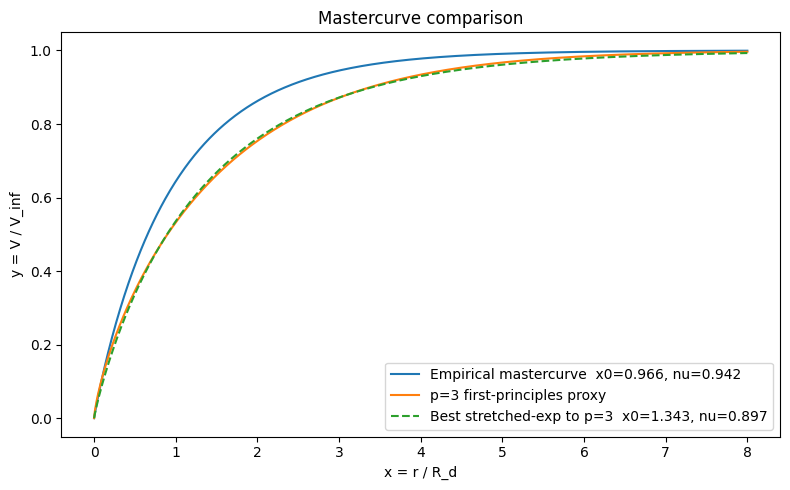

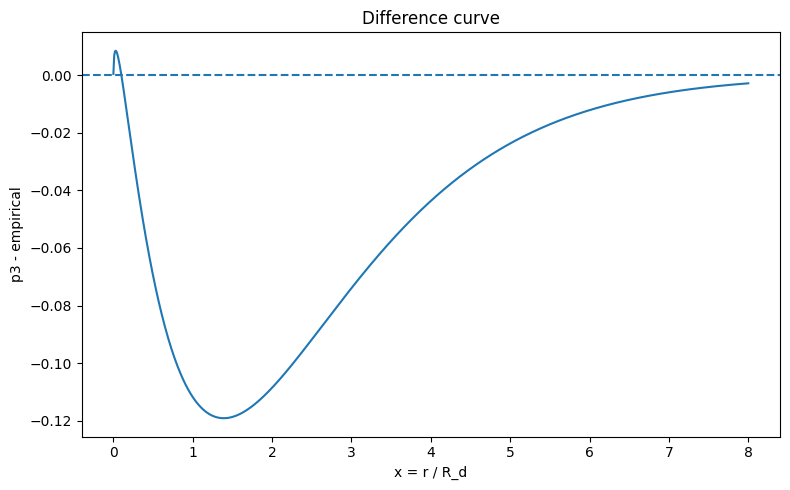

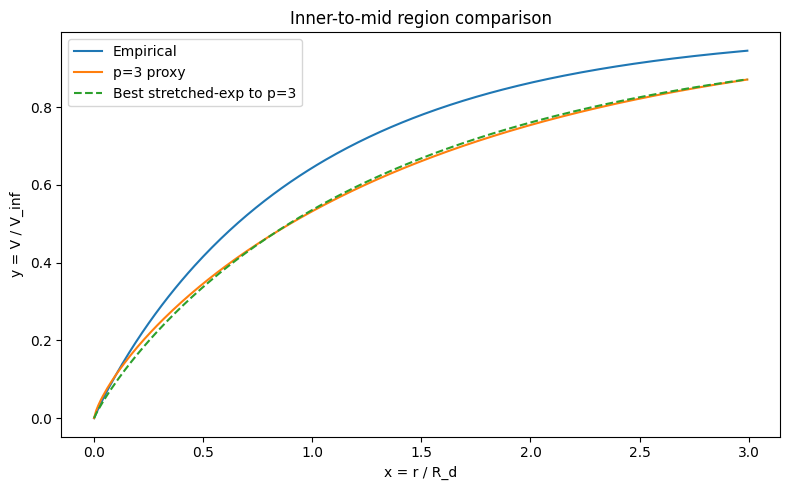

In [ ]:
# ============================================
# SELF-CONTAINED CELL:
# Compare p=3 first-principles spherical-exponential curve
# against the empirical mastercurve
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# -------------------------------------------------
# EMPIRICAL MASTERCURVE PARAMETERS
# -------------------------------------------------
x0_emp = 0.966
nu_emp = 0.942

# -------------------------------------------------
# GRID
# -------------------------------------------------
x = np.linspace(1e-4, 8.0, 800)

# -------------------------------------------------
# FIRST-PRINCIPLES p=3 SPHERICAL-EXPONENTIAL PROXY
#
# rho(r) = rho0 exp(-r/Rd)
# M(r)/Mtot = F(x)
# F(x) = 1 - 0.5 exp(-x) (x^2 + 2x + 2)
#
# Then:
# v/Vinf = F(x)^(1/4)
# -------------------------------------------------
F = 1.0 - 0.5 * np.exp(-x) * (x**2 + 2*x + 2)
F = np.clip(F, 0.0, None)
y_p3 = F**0.25

# -------------------------------------------------
# EMPIRICAL MASTERCURVE
# -------------------------------------------------
y_emp = 1.0 - np.exp(- (x / x0_emp)**nu_emp )

# -------------------------------------------------
# SIMPLE COMPARISON METRICS
# -------------------------------------------------
diff = y_p3 - y_emp
rmse = float(np.sqrt(np.mean(diff**2)))
mae = float(np.mean(np.abs(diff)))
max_abs = float(np.max(np.abs(diff)))

# characteristic radii for fixed fractions
fractions = [0.5, 0.8, 0.9, 0.95]

def crossing_x(xgrid, ygrid, frac):
    idx = np.where(ygrid >= frac)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return float(xgrid[0])
    x1, x2 = xgrid[i-1], xgrid[i]
    y1, y2 = ygrid[i-1], ygrid[i]
    if y2 == y1:
        return float(x2)
    return float(x1 + (frac - y1) * (x2 - x1) / (y2 - y1))

rows = []
for f in fractions:
    xp3 = crossing_x(x, y_p3, f)
    xemp = crossing_x(x, y_emp, f)
    rows.append({
        "fraction": f,
        "x_p3": xp3,
        "x_emp": xemp,
        "delta_x": xp3 - xemp,
        "ratio_x_p3_over_emp": xp3 / xemp if np.isfinite(xp3) and np.isfinite(xemp) and xemp != 0 else np.nan
    })

summary_df = pd.DataFrame(rows)

# -------------------------------------------------
# BEST-FIT STRETCHED-EXPONENTIAL TO p=3 CURVE
# so you can see what effective (x0, nu) the p=3 curve implies
# -------------------------------------------------
best = None
x0_grid = np.linspace(0.5, 1.8, 300)
nu_grid = np.linspace(0.5, 1.4, 300)

for x0_try in x0_grid:
    yy_base = x / x0_try
    for nu_try in nu_grid:
        yy = 1.0 - np.exp(-(yy_base**nu_try))
        err = np.mean((yy - y_p3)**2)
        if best is None or err < best[0]:
            best = (err, x0_try, nu_try)

_, x0_fit, nu_fit = best
y_fit_to_p3 = 1.0 - np.exp(- (x / x0_fit)**nu_fit )
rmse_fit = float(np.sqrt(np.mean((y_fit_to_p3 - y_p3)**2)))

# -------------------------------------------------
# OUTPUT
# -------------------------------------------------
display(Markdown("## p=3 spherical-exponential vs empirical mastercurve"))
display(pd.DataFrame([{
    "RMSE(p3 vs empirical)": rmse,
    "MAE(p3 vs empirical)": mae,
    "MaxAbs(p3 vs empirical)": max_abs,
    "best_fit_x0_to_p3": x0_fit,
    "best_fit_nu_to_p3": nu_fit,
    "RMSE(stretched-exp fit to p3)": rmse_fit
}]))

display(Markdown("## Radius comparison at fixed fractions"))
display(summary_df)

# -------------------------------------------------
# PLOTS
# -------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(x, y_emp, label=f"Empirical mastercurve  x0={x0_emp}, nu={nu_emp}")
plt.plot(x, y_p3, label="p=3 first-principles proxy")
plt.plot(x, y_fit_to_p3, "--", label=f"Best stretched-exp to p=3  x0={x0_fit:.3f}, nu={nu_fit:.3f}")
plt.xlabel("x = r / R_d")
plt.ylabel("y = V / V_inf")
plt.title("Mastercurve comparison")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x, diff)
plt.axhline(0, linestyle="--")
plt.xlabel("x = r / R_d")
plt.ylabel("p3 - empirical")
plt.title("Difference curve")
plt.tight_layout()
plt.show()

# optional zoom on inner region
mask = x <= 3.0
plt.figure(figsize=(8,5))
plt.plot(x[mask], y_emp[mask], label="Empirical")
plt.plot(x[mask], y_p3[mask], label="p=3 proxy")
plt.plot(x[mask], y_fit_to_p3[mask], "--", label="Best stretched-exp to p=3")
plt.xlabel("x = r / R_d")
plt.ylabel("y = V / V_inf")
plt.title("Inner-to-mid region comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# SELF-CONTAINED CELL:
# Solve the static spherical one-field MTS equation
#
#   psi'' + (2/r) psi' - lam * psi * (psi^2 - psi_inf^2) = kappa * rho(r)
#
# with spherical exponential baryon proxy
#
#   rho(r) = rho0 * exp(-r/Rd)
#
# and plot the predicted normalized rotation curve using
#
#   v^2 / Vinf^2 = (psi(r) - psi(0)) / (psi_inf - psi(0))
#
# Also compares against the empirical mastercurve
#   y_emp(x) = 1 - exp(-(x/x0)^nu)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from IPython.display import display, Markdown

# -------------------------------------------------
# EMPIRICAL MASTERCURVE FOR COMPARISON
# -------------------------------------------------
x0_emp = 0.966
nu_emp = 0.942

# -------------------------------------------------
# MODEL PARAMETERS (dimensionless working units)
# -------------------------------------------------
psi_inf = 1.0     # asymptotic strain vacuum value
lam = 1.0         # self-interaction strength
kappa = 6.0       # matter coupling strength
Rd = 1.0          # baryonic scale radius
rmax = 8.0        # outer integration radius in units of Rd
eps = 1e-4        # start away from r=0 for regularity
npts = 1400

# -------------------------------------------------
# SPHERICAL EXPONENTIAL BARYON DENSITY
# -------------------------------------------------
# rho(r) = rho0 exp(-r/Rd)
# We set rho0 so that total mass = 1 in these working units:
# Mtot = 8*pi*rho0*Rd^3 -> rho0 = 1/(8*pi*Rd^3)
# -------------------------------------------------
rho0 = 1.0 / (8.0 * np.pi * Rd**3)

def rho(r):
    return rho0 * np.exp(-r / Rd)

# -------------------------------------------------
# ODE SYSTEM
#
# y[0] = psi
# y[1] = m = psi'
#
# psi' = m
# m'   = -(2/r)m + lam*psi*(psi^2 - psi_inf^2) + kappa*rho(r)
# -------------------------------------------------
def rhs(r, y):
    psi, m = y
    dpsi = m
    dm = -(2.0 / r) * m + lam * psi * (psi**2 - psi_inf**2) + kappa * rho(r)
    return [dpsi, dm]

# -------------------------------------------------
# SHOOTING SETUP
#
# Regular center:
#   m(0)=0
#
# We do not start at r=0 directly. Instead start at eps with:
#   psi(eps) = psi_c
#   m(eps)   = 0
#
# and shoot on psi_c so that psi(rmax) -> psi_inf
# -------------------------------------------------
r_grid = np.linspace(eps, rmax, npts)

def integrate_for_center(psi_c):
    sol = solve_ivp(
        rhs,
        [eps, rmax],
        [psi_c, 0.0],
        t_eval=r_grid,
        rtol=1e-7,
        atol=1e-9,
        method="RK45",
    )
    return sol

def boundary_residual(psi_c):
    sol = integrate_for_center(psi_c)
    if not sol.success:
        return np.nan
    return sol.y[0, -1] - psi_inf

# -------------------------------------------------
# FIND A BRACKET FOR SHOOTING
# -------------------------------------------------
scan = np.linspace(-1.5 * psi_inf, 1.5 * psi_inf, 121)
vals = []

for p in scan:
    try:
        val = boundary_residual(p)
    except Exception:
        val = np.nan
    vals.append(val)

vals = np.array(vals, dtype=float)

bracket = None
for i in range(len(scan) - 1):
    a, b = vals[i], vals[i + 1]
    if np.isfinite(a) and np.isfinite(b) and a * b < 0:
        bracket = (scan[i], scan[i + 1])
        break

if bracket is None:
    display(Markdown("## Could not bracket a shooting solution with current parameters"))
    display(pd.DataFrame({"psi_c_trial": scan, "residual": vals}))
else:
    psi_c_best = brentq(boundary_residual, bracket[0], bracket[1])
    sol = integrate_for_center(psi_c_best)

    psi = sol.y[0]
    m = sol.y[1]
    r = sol.t

    psi0 = psi[0]

    # -------------------------------------------------
    # KINEMATIC PROJECTION
    #
    # v^2 / Vinf^2 = (psi - psi0) / (psi_inf - psi0)
    # so
    # y = v / Vinf = sqrt( ... )
    # -------------------------------------------------
    denom = max(psi_inf - psi0, 1e-12)
    y2 = (psi - psi0) / denom
    y2 = np.clip(y2, 0.0, 1.2)
    y_model = np.sqrt(np.clip(y2, 0.0, None))

    # empirical comparison on same x=r/Rd
    x = r / Rd
    y_emp = 1.0 - np.exp(- (x / x0_emp)**nu_emp )

    diff = y_model - y_emp
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    max_abs = float(np.max(np.abs(diff)))

    # -------------------------------------------------
    # CHARACTERISTIC RADII
    # -------------------------------------------------
    fractions = [0.5, 0.8, 0.9, 0.95]

    def crossing_x(xgrid, ygrid, frac):
        idx = np.where(ygrid >= frac)[0]
        if len(idx) == 0:
            return np.nan
        i = idx[0]
        if i == 0:
            return float(xgrid[0])
        x1, x2 = xgrid[i-1], xgrid[i]
        y1, y2 = ygrid[i-1], ygrid[i]
        if y2 == y1:
            return float(x2)
        return float(x1 + (frac - y1) * (x2 - x1) / (y2 - y1))

    rows = []
    for f in fractions:
        xm = crossing_x(x, y_model, f)
        xe = crossing_x(x, y_emp, f)
        rows.append({
            "fraction": f,
            "x_model": xm,
            "x_empirical": xe,
            "delta_x": xm - xe,
            "ratio_model_over_emp": xm / xe if np.isfinite(xm) and np.isfinite(xe) and xe != 0 else np.nan
        })

    compare_df = pd.DataFrame(rows)

    # -------------------------------------------------
    # OUTPUT TABLES
    # -------------------------------------------------
    display(Markdown("## Shooting solution summary"))
    display(pd.DataFrame([{
        "psi_c_best": psi_c_best,
        "psi(eps)": psi0,
        "psi(rmax)": psi[-1],
        "psi_inf_target": psi_inf,
        "RMSE(model vs empirical)": rmse,
        "MAE(model vs empirical)": mae,
        "MaxAbs(model vs empirical)": max_abs,
        "lambda": lam,
        "kappa": kappa,
        "rho0": rho0,
        "Rd": Rd
    }]))

    display(Markdown("## Radius comparison at fixed fractions"))
    display(compare_df)

    # -------------------------------------------------
    # PLOTS
    # -------------------------------------------------
    plt.figure(figsize=(8,5))
    plt.plot(x, y_emp, label=f"Empirical mastercurve x0={x0_emp}, nu={nu_emp}")
    plt.plot(x, y_model, label="One-field spherical numerical model")
    plt.xlabel("x = r / R_d")
    plt.ylabel("y = V / V_inf")
    plt.title("Numerical one-field model vs empirical mastercurve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, diff)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("x = r / R_d")
    plt.ylabel("model - empirical")
    plt.title("Difference curve")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, psi, label="psi(r)")
    plt.plot(x, m, label="m(r)=psi'(r)")
    plt.axhline(psi_inf, linestyle="--", label="psi_inf")
    plt.xlabel("x = r / R_d")
    plt.ylabel("field")
    plt.title("Field solution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # inner zoom
    mask = x <= 3.0
    plt.figure(figsize=(8,5))
    plt.plot(x[mask], y_emp[mask], label="Empirical")
    plt.plot(x[mask], y_model[mask], label="Numerical one-field model")
    plt.xlabel("x = r / R_d")
    plt.ylabel("y = V / V_inf")
    plt.title("Inner-to-mid comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Could not bracket a shooting solution with current parameters

,psi_c_trial,residual
0,-1.500,NaN
1,-1.475,NaN
2,-1.450,NaN
3,-1.425,NaN
4,-1.400,NaN
...,...,...
116,1.400,NaN
117,1.425,NaN
118,1.450,NaN
119,1.475,NaN


## Bracket scan

,psi_c_trial,residual
0,0.0000,-0.997240
1,0.0125,-0.997064
2,0.0250,-0.996884
3,0.0375,-0.996697
4,0.0500,-0.996501
...,...,...
116,1.4500,NaN
117,1.4625,NaN
118,1.4750,NaN
119,1.4875,NaN


## Shooting solution summary

,psi_c_best,psi(eps),psi(rmax),psi_inf_target,RMSE(model vs empirical),MAE(model vs empirical),MaxAbs(model vs empirical),lambda,kappa,rho0,Rd
0,0.994185,0.994185,1.0,1.0,0.102874,0.07861,0.195111,0.15,0.35,0.039789,1.0


## Radius comparison at fixed fractions

,fraction,x_model,x_empirical,delta_x,ratio_model_over_emp
0,0.50,1.158767,0.654642,0.504124,1.770076
1,0.80,2.651215,1.600947,1.050268,1.656029
2,0.90,3.750079,2.341505,1.408574,1.601568
3,0.95,4.811375,3.096131,1.715244,1.553996


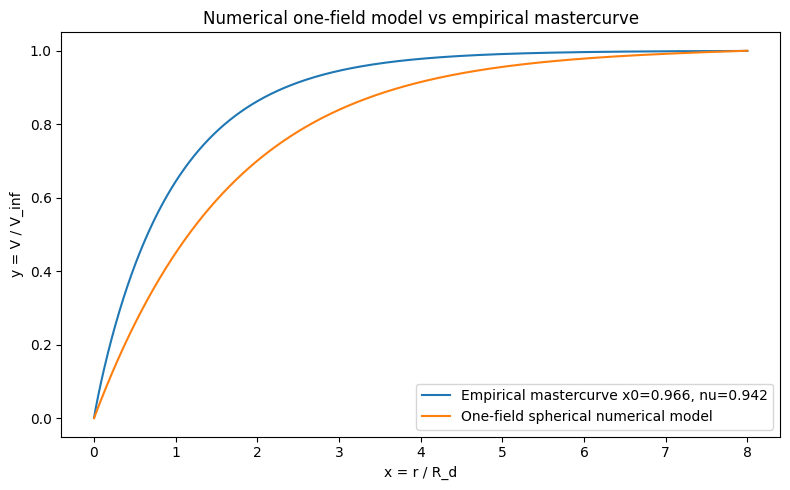

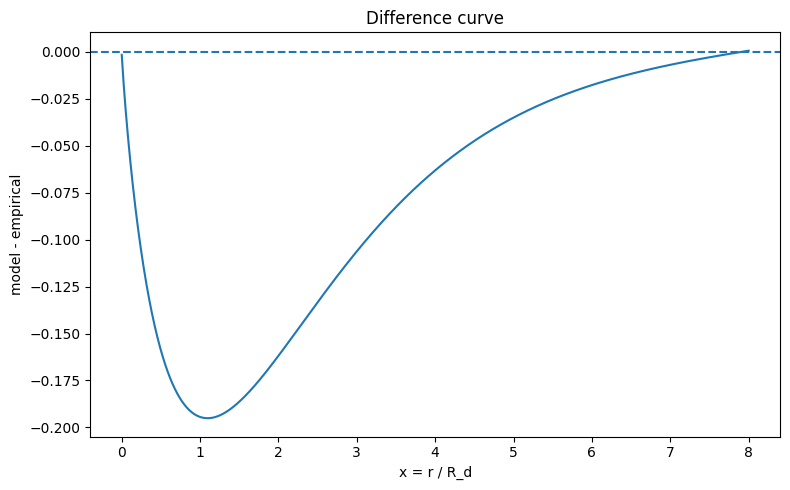

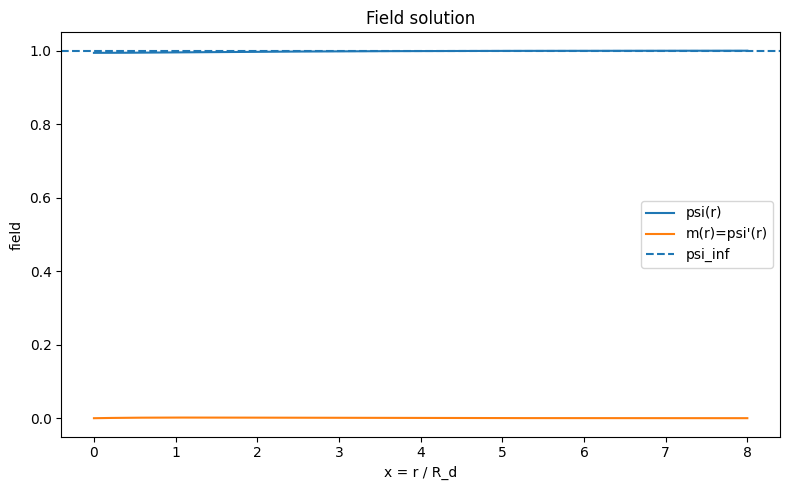

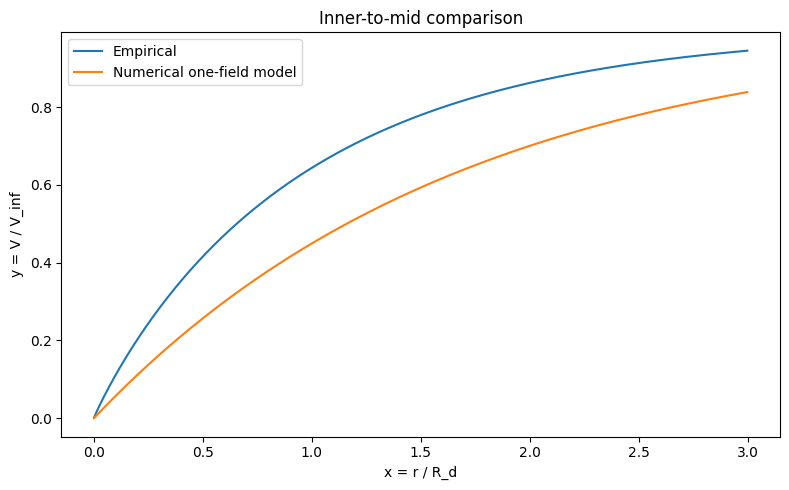

In [ ]:
# ============================================
# SELF-CONTAINED STABLE CELL:
# Solve the static spherical one-field MTS equation
#
#   psi'' + (2/r) psi' - lam * psi * (psi^2 - psi_inf^2) = kappa * rho(r)
#
# using a more stable shooting setup
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from IPython.display import display, Markdown

# -------------------------------------------------
# EMPIRICAL MASTERCURVE
# -------------------------------------------------
x0_emp = 0.966
nu_emp = 0.942

# -------------------------------------------------
# STABLE WORKING PARAMETERS
# -------------------------------------------------
psi_inf = 1.0
lam = 0.15
kappa = 0.35
Rd = 1.0
rmax = 8.0
eps = 1e-3
npts = 1600

# spherical exponential baryon proxy with total mass = 1
rho0 = 1.0 / (8.0 * np.pi * Rd**3)

def rho(r):
    return rho0 * np.exp(-r / Rd)

# -------------------------------------------------
# ODE SYSTEM
# y[0] = psi
# y[1] = m = psi'
# -------------------------------------------------
def rhs(r, y):
    psi, m = y

    # stop runaway solutions from poisoning the scan
    if not np.isfinite(psi) or not np.isfinite(m):
        return [0.0, 0.0]
    if abs(psi) > 1e6 or abs(m) > 1e6:
        return [0.0, 0.0]

    dpsi = m
    dm = -(2.0 / r) * m + lam * psi * (psi**2 - psi_inf**2) + kappa * rho(r)
    return [dpsi, dm]

# terminal event to stop blow-up
def blowup_event(r, y):
    psi, m = y
    val = 1e4 - max(abs(psi), abs(m))
    return val

blowup_event.terminal = True
blowup_event.direction = -1

r_grid = np.linspace(eps, rmax, npts)

def integrate_for_center(psi_c):
    try:
        sol = solve_ivp(
            rhs,
            [eps, rmax],
            [psi_c, 0.0],
            t_eval=r_grid,
            events=blowup_event,
            rtol=1e-7,
            atol=1e-9,
            max_step=0.05,
            method="RK45",
        )
        return sol
    except Exception:
        return None

def boundary_residual(psi_c):
    sol = integrate_for_center(psi_c)
    if sol is None or (not sol.success and len(sol.t) < 5):
        return np.nan
    if len(sol.t) < len(r_grid):
        return np.nan
    psi_end = sol.y[0, -1]
    if not np.isfinite(psi_end):
        return np.nan
    return psi_end - psi_inf

# -------------------------------------------------
# BRACKET SEARCH
# -------------------------------------------------
scan = np.linspace(0.0, 1.5, 121)
vals = np.array([boundary_residual(p) for p in scan], dtype=float)

display(Markdown("## Bracket scan"))
display(pd.DataFrame({"psi_c_trial": scan, "residual": vals}))

bracket = None
for i in range(len(scan) - 1):
    a, b = vals[i], vals[i + 1]
    if np.isfinite(a) and np.isfinite(b) and a * b < 0:
        bracket = (scan[i], scan[i + 1])
        break

if bracket is None:
    finite = np.isfinite(vals)
    if np.any(finite):
        i_best = np.nanargmin(np.abs(vals))
        display(Markdown("## No sign-change bracket found"))
        display(pd.DataFrame([{
            "best_trial_psi_c": scan[i_best],
            "best_residual": vals[i_best],
            "suggestion": "lower lam or kappa further, or increase rmax"
        }]))
    else:
        display(Markdown("## No finite scan values found"))
        display(pd.DataFrame([{
            "suggestion": "try much smaller lam and kappa, or larger eps"
        }]))
else:
    psi_c_best = brentq(boundary_residual, bracket[0], bracket[1])
    sol = integrate_for_center(psi_c_best)

    psi = sol.y[0]
    m = sol.y[1]
    r = sol.t
    x = r / Rd

    psi0 = psi[0]
    denom = max(psi_inf - psi0, 1e-12)

    # kinematic projection
    y2 = (psi - psi0) / denom
    y2 = np.clip(y2, 0.0, 1.2)
    y_model = np.sqrt(np.clip(y2, 0.0, None))

    # empirical comparison
    y_emp = 1.0 - np.exp(- (x / x0_emp)**nu_emp)
    diff = y_model - y_emp

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    max_abs = float(np.max(np.abs(diff)))

    def crossing_x(xgrid, ygrid, frac):
        idx = np.where(ygrid >= frac)[0]
        if len(idx) == 0:
            return np.nan
        i = idx[0]
        if i == 0:
            return float(xgrid[0])
        x1, x2 = xgrid[i-1], xgrid[i]
        y1, y2 = ygrid[i-1], ygrid[i]
        if y2 == y1:
            return float(x2)
        return float(x1 + (frac - y1) * (x2 - x1) / (y2 - y1))

    rows = []
    for f in [0.5, 0.8, 0.9, 0.95]:
        xm = crossing_x(x, y_model, f)
        xe = crossing_x(x, y_emp, f)
        rows.append({
            "fraction": f,
            "x_model": xm,
            "x_empirical": xe,
            "delta_x": xm - xe,
            "ratio_model_over_emp": xm / xe if np.isfinite(xm) and np.isfinite(xe) and xe != 0 else np.nan
        })
    compare_df = pd.DataFrame(rows)

    display(Markdown("## Shooting solution summary"))
    display(pd.DataFrame([{
        "psi_c_best": psi_c_best,
        "psi(eps)": psi0,
        "psi(rmax)": psi[-1],
        "psi_inf_target": psi_inf,
        "RMSE(model vs empirical)": rmse,
        "MAE(model vs empirical)": mae,
        "MaxAbs(model vs empirical)": max_abs,
        "lambda": lam,
        "kappa": kappa,
        "rho0": rho0,
        "Rd": Rd
    }]))

    display(Markdown("## Radius comparison at fixed fractions"))
    display(compare_df)

    plt.figure(figsize=(8,5))
    plt.plot(x, y_emp, label=f"Empirical mastercurve x0={x0_emp}, nu={nu_emp}")
    plt.plot(x, y_model, label="One-field spherical numerical model")
    plt.xlabel("x = r / R_d")
    plt.ylabel("y = V / V_inf")
    plt.title("Numerical one-field model vs empirical mastercurve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, diff)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("x = r / R_d")
    plt.ylabel("model - empirical")
    plt.title("Difference curve")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, psi, label="psi(r)")
    plt.plot(x, m, label="m(r)=psi'(r)")
    plt.axhline(psi_inf, linestyle="--", label="psi_inf")
    plt.xlabel("x = r / R_d")
    plt.ylabel("field")
    plt.title("Field solution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    mask = x <= 3.0
    plt.figure(figsize=(8,5))
    plt.plot(x[mask], y_emp[mask], label="Empirical")
    plt.plot(x[mask], y_model[mask], label="Numerical one-field model")
    plt.xlabel("x = r / R_d")
    plt.ylabel("y = V / V_inf")
    plt.title("Inner-to-mid comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Monotone accumulation summary

,A,B,n,q,psi(eps),psi(rmax),m_max,m(rmax),monotone_psi,RMSE(model vs empirical),MAE(model vs empirical),MaxAbs(model vs empirical)
0,18.0,2.5,2.0,1.0,0.0,0.707918,0.168336,0.03087,True,0.154367,0.12883,0.258241


## Radius comparison at fixed fractions

,fraction,x_model,x_empirical,delta_x,ratio_model_over_emp
0,0.50,1.400839,0.654642,0.746197,2.139855
1,0.80,3.447281,1.600947,1.846334,2.153276
2,0.90,4.957020,2.341505,2.615515,2.117023
3,0.95,6.168155,3.096131,3.072025,1.992214


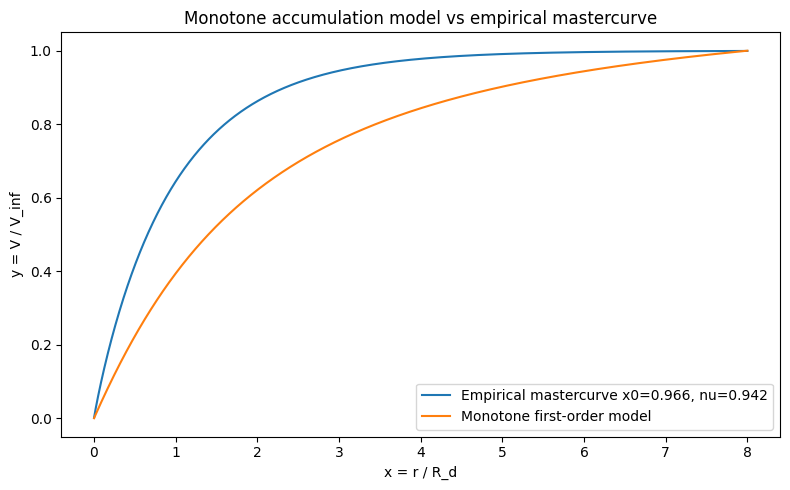

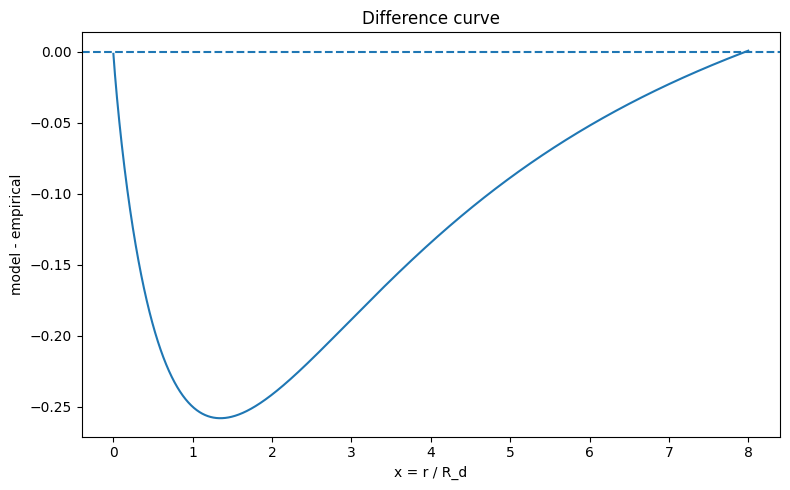

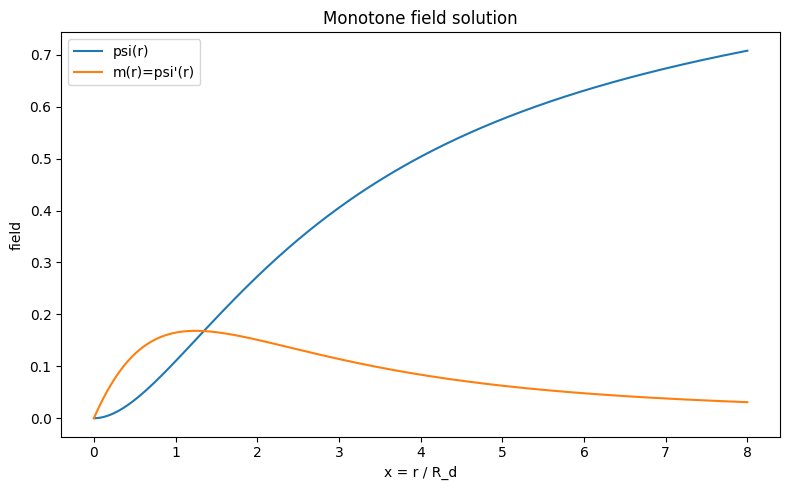

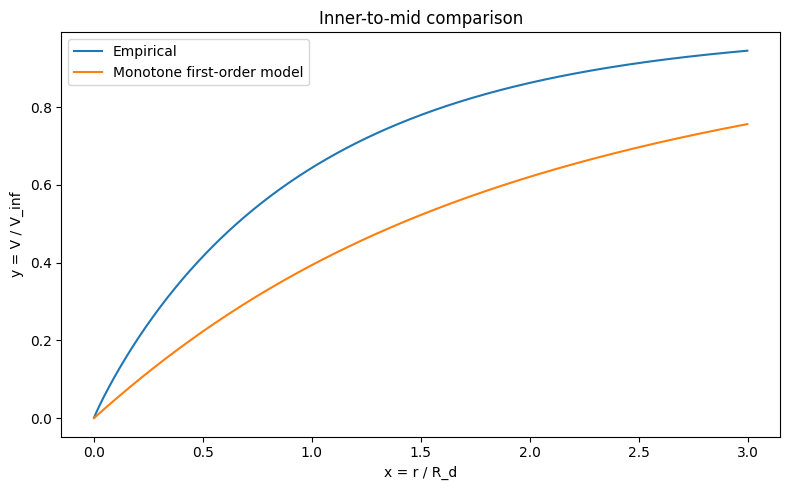

In [ ]:
# ============================================
# SELF-CONTAINED CELL:
# Monotone first-order accumulation test
#
#   m'(r) + (q/r) m(r) = A * rho(r) - B * m(r)^n
#   psi'(r) = m(r)
#
# spherical exponential baryon proxy:
#   rho(r) = rho0 * exp(-r/Rd)
#
# projected rotation curve:
#   v^2 / Vinf^2 = (psi(r) - psi(0)) / (psi(rmax) - psi(0))
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Markdown

# -------------------------------------------------
# EMPIRICAL MASTERCURVE
# -------------------------------------------------
x0_emp = 0.966
nu_emp = 0.942

# -------------------------------------------------
# MODEL PARAMETERS
# -------------------------------------------------
A = 18.0     # source amplitude
B = 2.5      # nonlinear damping
n = 2.0      # damping power
q = 1.0      # geometric dilution term
Rd = 1.0
rmax = 8.0
eps = 1e-3
npts = 1600

# total mass = 1 spherical exponential proxy
rho0 = 1.0 / (8.0 * np.pi * Rd**3)

def rho(r):
    return rho0 * np.exp(-r / Rd)

# -------------------------------------------------
# ODE SYSTEM
# y[0] = psi
# y[1] = m = psi'
#
# psi' = m
# m'   = A*rho(r) - B*m^n - (q/r)*m
# -------------------------------------------------
def rhs(r, y):
    psi, m = y

    if not np.isfinite(psi) or not np.isfinite(m):
        return [0.0, 0.0]
    if abs(psi) > 1e6 or abs(m) > 1e6:
        return [0.0, 0.0]

    m_pos = max(m, 0.0)
    dpsi = m_pos
    dm = A * rho(r) - B * (m_pos**n) - (q / r) * m_pos
    return [dpsi, dm]

r_grid = np.linspace(eps, rmax, npts)

# regular center: psi(eps)=0, m(eps)=0
sol = solve_ivp(
    rhs,
    [eps, rmax],
    [0.0, 0.0],
    t_eval=r_grid,
    rtol=1e-7,
    atol=1e-9,
    max_step=0.02,
    method="RK45",
)

if not sol.success:
    display(Markdown("## Solver failed"))
    display(pd.DataFrame([{"message": sol.message}]))
else:
    psi = sol.y[0]
    m = np.maximum(sol.y[1], 0.0)
    r = sol.t
    x = r / Rd

    psi0 = psi[0]
    psi_end = psi[-1]
    denom = max(psi_end - psi0, 1e-12)

    y2 = (psi - psi0) / denom
    y2 = np.clip(y2, 0.0, 1.2)
    y_model = np.sqrt(np.clip(y2, 0.0, None))

    y_emp = 1.0 - np.exp(- (x / x0_emp)**nu_emp)
    diff = y_model - y_emp

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    max_abs = float(np.max(np.abs(diff)))

    monotone_m = bool(np.all(np.diff(m) >= -1e-8) or np.all(m >= -1e-10))
    monotone_psi = bool(np.all(np.diff(psi) >= -1e-8))

    def crossing_x(xgrid, ygrid, frac):
        idx = np.where(ygrid >= frac)[0]
        if len(idx) == 0:
            return np.nan
        i = idx[0]
        if i == 0:
            return float(xgrid[0])
        x1, x2 = xgrid[i-1], xgrid[i]
        y1, y2 = ygrid[i-1], ygrid[i]
        if y2 == y1:
            return float(x2)
        return float(x1 + (frac - y1) * (x2 - x1) / (y2 - y1))

    rows = []
    for f in [0.5, 0.8, 0.9, 0.95]:
        xm = crossing_x(x, y_model, f)
        xe = crossing_x(x, y_emp, f)
        rows.append({
            "fraction": f,
            "x_model": xm,
            "x_empirical": xe,
            "delta_x": xm - xe,
            "ratio_model_over_emp": xm / xe if np.isfinite(xm) and np.isfinite(xe) and xe != 0 else np.nan
        })
    compare_df = pd.DataFrame(rows)

    display(Markdown("## Monotone accumulation summary"))
    display(pd.DataFrame([{
        "A": A,
        "B": B,
        "n": n,
        "q": q,
        "psi(eps)": psi0,
        "psi(rmax)": psi_end,
        "m_max": float(np.max(m)),
        "m(rmax)": float(m[-1]),
        "monotone_psi": monotone_psi,
        "RMSE(model vs empirical)": rmse,
        "MAE(model vs empirical)": mae,
        "MaxAbs(model vs empirical)": max_abs
    }]))

    display(Markdown("## Radius comparison at fixed fractions"))
    display(compare_df)

    plt.figure(figsize=(8,5))
    plt.plot(x, y_emp, label=f"Empirical mastercurve x0={x0_emp}, nu={nu_emp}")
    plt.plot(x, y_model, label="Monotone first-order model")
    plt.xlabel("x = r / R_d")
    plt.ylabel("y = V / V_inf")
    plt.title("Monotone accumulation model vs empirical mastercurve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, diff)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("x = r / R_d")
    plt.ylabel("model - empirical")
    plt.title("Difference curve")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, psi, label="psi(r)")
    plt.plot(x, m, label="m(r)=psi'(r)")
    plt.xlabel("x = r / R_d")
    plt.ylabel("field")
    plt.title("Monotone field solution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    mask = x <= 3.0
    plt.figure(figsize=(8,5))
    plt.plot(x[mask], y_emp[mask], label="Empirical")
    plt.plot(x[mask], y_model[mask], label="Monotone first-order model")
    plt.xlabel("x = r / R_d")
    plt.ylabel("y = V / V_inf")
    plt.title("Inner-to-mid comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# SPARC TEST: DIRECT TRANSPORT LAW FOR m(r) -- SAFE RESTART
#
# Physics model:
#
#   dm/dr + m/ell_eff(r) = kappa * g_b(r)
#
#   g_b(r) = v_bar(r)^2 / r
#   ell_eff(r) = Rd * s(r)^alpha
#   s(r) = | d ln(v_bar) / d ln(r) |
#
#   x(r) = ∫_0^r m(s) ds
#
#   V(r)/Vinf = 1 - exp(-(x(r)/x0)^nu)
#
# Global fit parameters:
#   alpha, kappa, x0, nu
#
# Per-galaxy fitted parameter:
#   Vinf only
#
# This version is designed to survive a fresh session:
#   - smaller coarse grid
#   - checks for missing files
#   - checks for empty scans
#   - saves outputs only if something worked
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from IPython.display import display, Markdown

# -------------------------------------------------
# PATHS
# -------------------------------------------------
BASE_DIR = Path("/content")

backbone_files = sorted((BASE_DIR / "backbone_results_v2").rglob("*_backbone.csv"))
backbone_map = {fp.stem.replace("_backbone", ""): fp for fp in backbone_files}

rotmod_files = []
for d in [
    BASE_DIR / "rotmod",
    BASE_DIR / "extracted_rotmod" / "Rotmod_LTG_(4)",
    BASE_DIR / "extracted_rotmod" / "Rotmod_LTG_4",
]:
    if d.exists():
        rotmod_files.extend(d.rglob("*_rotmod.dat"))

rotmod_files = sorted(set(rotmod_files))
rotmod_map = {}
for fp in rotmod_files:
    g = fp.stem.replace("_rotmod", "")
    if g not in rotmod_map or str(fp).startswith("/content/rotmod/"):
        rotmod_map[g] = fp

names = sorted(set(backbone_map.keys()) & set(rotmod_map.keys()))

print(f"Found {len(backbone_map)} backbone files")
print(f"Found {len(rotmod_map)} rotmod files")
print(f"Matched {len(names)} galaxies")

# -------------------------------------------------
# GLOBAL SETTINGS
# -------------------------------------------------
UPS_D = 0.5
UPS_B = 0.7
SLOPE_FLOOR = 0.05
M_FLOOR = 1e-12

# small/stable coarse scan
alpha_grid = np.array([0.0, 0.3, 0.6])
kappa_grid = np.array([1e-4, 1e-3, 1e-2])
x0_grid    = np.array([0.05, 0.2, 1.0])
nu_grid    = np.array([0.9, 1.4, 2.2])

# -------------------------------------------------
# LOADERS
# -------------------------------------------------
def read_backbone_csv(fp):
    df = pd.read_csv(fp)
    df.columns = [str(c).strip().lower() for c in df.columns]

    def find_col(cands):
        for c in cands:
            if c in df.columns:
                return c
        for c in df.columns:
            for cand in cands:
                if cand in c:
                    return c
        return None

    r_col = find_col(["r", "rad", "radius"])
    v_col = find_col(["vobs", "v_obs", "vrot", "v_rot", "v"])
    e_col = find_col(["evobs", "vobs_err", "err", "sigma", "ev", "v_err"])

    if r_col is None or v_col is None:
        raise ValueError(f"Could not find r/v columns in {fp.name}")

    out = pd.DataFrame({
        "r": pd.to_numeric(df[r_col], errors="coerce"),
        "vobs": pd.to_numeric(df[v_col], errors="coerce"),
    })

    if e_col is not None:
        out["err"] = pd.to_numeric(df[e_col], errors="coerce")
    else:
        out["err"] = np.nan

    out = out.dropna(subset=["r", "vobs"])
    out = out[out["r"] > 0].sort_values("r").reset_index(drop=True)
    out["err"] = out["err"].fillna(np.maximum(5.0, 0.1 * np.abs(out["vobs"])))
    return out

def read_rotmod_dat(fp):
    df = pd.read_csv(fp, sep=r"\s+", engine="python", comment="#", header=None)
    if df.shape[1] < 6:
        raise ValueError(f"Rotmod file has too few columns: {fp.name}")

    out = pd.DataFrame({
        "r": pd.to_numeric(df.iloc[:, 0], errors="coerce"),
        "vgas": pd.to_numeric(df.iloc[:, 3], errors="coerce"),
        "vdisk": pd.to_numeric(df.iloc[:, 4], errors="coerce"),
        "vbulge": pd.to_numeric(df.iloc[:, 5], errors="coerce"),
    })

    out = out.dropna(subset=["r"])
    out = out[out["r"] > 0].sort_values("r").reset_index(drop=True)
    return out

def load_one_galaxy(name):
    obs = read_backbone_csv(backbone_map[name])
    rot = read_rotmod_dat(rotmod_map[name])

    base = obs.copy()
    xr = rot["r"].to_numpy(float)

    for comp in ["vgas", "vdisk", "vbulge"]:
        yr = rot[comp].to_numpy(float)
        good = np.isfinite(xr) & np.isfinite(yr)
        if np.sum(good) < 2:
            raise ValueError(f"Not enough valid rotmod values for {name} {comp}")
        base[comp] = np.interp(
            base["r"].to_numpy(float),
            xr[good], yr[good],
            left=yr[good][0],
            right=yr[good][-1]
        )

    return base[["r", "vobs", "err", "vgas", "vdisk", "vbulge"]]

# -------------------------------------------------
# HELPERS
# -------------------------------------------------
def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def crossing_radius(r, y, frac):
    ymax = np.max(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return float(r[0])
    r1, r2 = r[i-1], r[i]
    y1, y2 = y[i-1], y[i]
    if y2 == y1:
        return float(r2)
    return float(r1 + (target - y1) * (r2 - r1) / (y2 - y1))

def safe_log_slope(r, y):
    r = np.asarray(r, float)
    y = np.asarray(y, float)
    out = np.full_like(r, np.nan, dtype=float)
    good = np.isfinite(r) & np.isfinite(y) & (r > 0) & (y > 0)
    if np.sum(good) < 3:
        return out
    lr = np.log(r[good])
    ly = np.log(y[good])
    out_good = np.gradient(ly, lr, edge_order=1)
    out[good] = out_good
    return out

def build_baryons(df):
    r = df["r"].to_numpy(float)
    vgas = np.maximum(df["vgas"].to_numpy(float), 0.0)
    vdisk = np.maximum(df["vdisk"].to_numpy(float), 0.0)
    vbul  = np.maximum(df["vbulge"].to_numpy(float), 0.0)

    vbar2 = vgas**2 + UPS_D * vdisk**2 + UPS_B * vbul**2
    vbar2 = np.maximum(vbar2, 0.0)
    vbar = np.sqrt(vbar2)
    gb = vbar2 / np.maximum(r, 1e-8)

    return r, vbar, gb

def response_shape_raw_x(x, x0, nu):
    x = np.maximum(np.asarray(x, dtype=float), 0.0)
    x0 = max(float(x0), 1e-12)
    nu = max(float(nu), 1e-6)
    return 1.0 - np.exp(-np.power(x / x0, nu))

def fit_vinf(vobs, err, shape):
    err = np.where(err > 0, err, np.maximum(5.0, 0.1 * np.abs(vobs)))

    def chi2_for(logV):
        Vinf = 10**logV
        pred = Vinf * shape
        return np.sum(((vobs - pred) / err) ** 2)

    res = minimize_scalar(chi2_for, bounds=(0.0, 4.0), method="bounded")
    Vinf = 10**res.x
    pred = Vinf * shape
    chi2 = np.sum(((vobs - pred) / err) ** 2)
    redchi2 = chi2 / max(len(vobs) - 1, 1)
    rmse = float(np.sqrt(np.mean((vobs - pred) ** 2)))
    return Vinf, pred, chi2, redchi2, rmse

# -------------------------------------------------
# TRANSPORT SOLVER
# -------------------------------------------------
def solve_transport_m(r, gb, ell_eff, kappa):
    n = len(r)
    m = np.zeros(n, dtype=float)

    for i in range(1, n):
        dr = r[i] - r[i-1]
        if dr <= 0:
            m[i] = m[i-1]
            continue

        ell = max(0.5 * (ell_eff[i] + ell_eff[i-1]), 1e-12)
        src = 0.5 * (gb[i] + gb[i-1])

        m[i] = (m[i-1] + dr * kappa * src) / (1.0 + dr / ell)
        m[i] = max(m[i], M_FLOOR)

    return m

# -------------------------------------------------
# MODEL EVALUATION
# -------------------------------------------------
def evaluate_model(alpha, kappa, x0, nu):
    rows = []
    pooled = []

    for name in names:
        try:
            df = load_one_galaxy(name)
            if len(df) < 10:
                continue

            r, vbar, gb = build_baryons(df)

            r80_bar = crossing_radius(r, vbar, 0.8)
            if not np.isfinite(r80_bar) or r80_bar <= 0:
                continue
            Rd = max(r80_bar / 1.8, r[0])

            slope = safe_log_slope(r, vbar)
            slope_abs = np.where(
                np.isfinite(slope),
                np.maximum(np.abs(slope), SLOPE_FLOOR),
                SLOPE_FLOOR
            )

            ell_eff = Rd * np.power(slope_abs, alpha)
            m = solve_transport_m(r, gb, ell_eff, kappa)
            x_raw = cumulative_trapz(r, m)

            if not np.all(np.isfinite(x_raw)) or x_raw[-1] <= 0:
                continue

            shape = response_shape_raw_x(x_raw, x0=x0, nu=nu)
            if not np.all(np.isfinite(shape)):
                continue

            Vinf, pred, chi2, redchi2, rmse = fit_vinf(
                df["vobs"].to_numpy(float),
                df["err"].to_numpy(float),
                shape
            )

            rows.append({
                "galaxy": name,
                "npts": len(df),
                "Rd": Rd,
                "alpha": alpha,
                "kappa": kappa,
                "x0": x0,
                "nu": nu,
                "x_rmax": float(x_raw[-1]),
                "m_rmax": float(m[-1]),
                "Vinf_fit": Vinf,
                "chi2": chi2,
                "redchi2": redchi2,
                "rmse": rmse,
            })

            for i in range(len(r)):
                pooled.append({
                    "galaxy": name,
                    "r": r[i],
                    "vobs": float(df["vobs"].iloc[i]),
                    "vpred": float(pred[i]),
                    "vbar": vbar[i],
                    "gb": gb[i],
                    "slope_abs": slope_abs[i],
                    "ell_eff": ell_eff[i],
                    "m": m[i],
                    "x_raw": x_raw[i],
                    "shape": shape[i],
                })

        except Exception:
            continue

    return pd.DataFrame(rows), pd.DataFrame(pooled)

# -------------------------------------------------
# COARSE GRID SCAN
# -------------------------------------------------
scan_rows = []
best = {"obj": np.inf, "alpha": None, "kappa": None, "x0": None, "nu": None, "summary": None, "pooled": None}

for alpha in alpha_grid:
    for kappa in kappa_grid:
        for x0 in x0_grid:
            for nu in nu_grid:
                summary_df, pooled_df = evaluate_model(alpha, kappa, x0, nu)

                if len(summary_df) == 0:
                    continue

                med_rmse = float(summary_df["rmse"].median())
                med_red  = float(summary_df["redchi2"].median())
                obj = med_rmse + 0.25 * med_red

                scan_rows.append({
                    "alpha": alpha,
                    "kappa": kappa,
                    "x0": x0,
                    "nu": nu,
                    "median_rmse": med_rmse,
                    "median_redchi2": med_red,
                    "objective": obj,
                    "n_galaxies": len(summary_df),
                })

                if obj < best["obj"]:
                    best = {
                        "obj": obj,
                        "alpha": alpha,
                        "kappa": kappa,
                        "x0": x0,
                        "nu": nu,
                        "summary": summary_df.copy(),
                        "pooled": pooled_df.copy(),
                    }

# -------------------------------------------------
# HANDLE EMPTY SCAN SAFELY
# -------------------------------------------------
if len(scan_rows) == 0:
    print("No successful model evaluations were produced.")
    print("Likely causes:")
    print("- file paths not restored yet")
    print("- backbone/rotmod columns parsed differently in this session")
    print("- all candidate models produced invalid x_raw or shape")
else:
    scan_df = pd.DataFrame(scan_rows).sort_values("objective").reset_index(drop=True)

    display(Markdown("## Best coarse-grid points"))
    display(scan_df.head(20))

    summary = best["summary"].sort_values(["redchi2", "rmse"]).reset_index(drop=True)
    pooled_df = best["pooled"]

    out_dir = BASE_DIR / "mts_transport_m_sparc_rawx"
    out_dir.mkdir(exist_ok=True)

    scan_df.to_csv(out_dir / "transport_m_rawx_scan.csv", index=False)
    summary.to_csv(out_dir / "transport_m_rawx_summary.csv", index=False)
    pooled_df.to_csv(out_dir / "transport_m_rawx_pooled.csv", index=False)

    display(Markdown("## Best non-degenerate transport-law model"))
    display(pd.DataFrame([{
        "alpha_best": best["alpha"],
        "kappa_best": best["kappa"],
        "x0_best": best["x0"],
        "nu_best": best["nu"],
        "median_rmse": float(summary["rmse"].median()),
        "median_redchi2": float(summary["redchi2"].median()),
        "n_galaxies": len(summary),
    }]))

    display(Markdown("## Closed-loop galaxy summary"))
    display(summary)

    display(Markdown(f"### Median RMSE: **{summary['rmse'].median():.6f}**"))
    display(Markdown(f"### Median reduced chi^2: **{summary['redchi2'].median():.6f}**"))
    display(Markdown(f"## Saved outputs to `{out_dir}`"))

Found 171 backbone files
Found 175 rotmod files
Matched 171 galaxies


## Best coarse-grid points

,alpha,kappa,x0,nu,median_rmse,median_redchi2,objective,n_galaxies
0,0.0,0.0010,0.20,0.9,18.000698,4.604080,19.151718,124
1,0.6,0.0010,0.20,0.9,18.033259,4.518949,19.162996,124
2,0.3,0.0010,0.20,0.9,18.066400,4.584905,19.212626,124
3,0.6,0.0100,1.00,0.9,19.331657,4.787610,20.528559,124
4,0.6,0.0001,0.05,0.9,19.181214,5.423488,20.537086,124
5,0.0,0.0010,0.20,1.4,19.277877,5.953413,20.766230,124
6,0.3,0.0100,1.00,0.9,19.583671,4.822610,20.789324,124
7,0.3,0.0001,0.05,0.9,19.530418,5.664225,20.946474,124
8,0.0,0.0001,0.05,0.9,19.530568,5.669050,20.947831,124
9,0.3,0.0010,0.20,1.4,19.490790,5.971871,20.983758,124


## Best non-degenerate transport-law model

,alpha_best,kappa_best,x0_best,nu_best,median_rmse,median_redchi2,n_galaxies
0,0.0,0.001,0.2,0.9,18.000698,4.60408,124


## Closed-loop galaxy summary

,galaxy,npts,Rd,alpha,kappa,x0,nu,x_rmax,m_rmax,Vinf_fit,chi2,redchi2,rmse
0,NGC2366,26,1.039171,0.0,0.001,0.2,0.9,1.102516,0.169197,54.471173,25.168012,1.006720,4.923665
1,D631-7,16,0.614019,0.0,0.001,0.2,0.9,0.688243,0.038694,58.111879,15.499827,1.033322,4.996978
2,NGC2915,30,0.340000,0.0,0.001,0.2,0.9,1.017546,0.019111,80.016237,39.707651,1.369229,6.780372
3,F583-1,25,5.232460,0.0,0.001,0.2,0.9,5.518849,0.526006,73.375407,36.460205,1.519175,7.222173
4,NGC3741,21,0.426770,0.0,0.001,0.2,0.9,0.193337,0.013216,86.040355,31.325763,1.566288,6.107684
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,IC4202,32,0.817214,0.0,0.001,0.2,0.9,70.994614,0.771571,186.549993,418.911724,13.513281,55.060849
120,ESO079-G014,15,4.500448,0.0,0.001,0.2,0.9,45.795228,3.232814,95.320761,252.369934,18.026424,52.037939
121,UGC05764,10,0.992055,0.0,0.001,0.2,0.9,0.322674,0.146314,87.411633,173.832128,19.314681,20.964711
122,UGC11455,36,3.907720,0.0,0.001,0.2,0.9,411.923665,3.139546,162.591541,775.765939,22.164741,92.499891


### Median RMSE: **18.000698**

### Median reduced chi^2: **4.604080**

## Saved outputs to `/content/mts_transport_m_sparc_rawx`

In [ ]:
# ============================================================
# FAST SPARC TEST: DIRECT COORDINATE-GROWTH LAW
#
# Stage 1: tiny coarse scan on a subset
# Stage 2: best coarse parameters run on full sample
#
# Model:
#   dx/dr = A * g_b(r)^p * s(r)^q / (1 + r/(rt*Rd))
#   V/Vinf = 1 - exp(-(x/x0)^nu)
#
# Fits only Vinf per galaxy.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from IPython.display import display, Markdown

# -------------------------------------------------
# PATHS
# -------------------------------------------------
BASE_DIR = Path("/content")

backbone_files = sorted((BASE_DIR / "backbone_results_v2").rglob("*_backbone.csv"))
backbone_map = {fp.stem.replace("_backbone", ""): fp for fp in backbone_files}

rotmod_files = []
for d in [
    BASE_DIR / "rotmod",
    BASE_DIR / "extracted_rotmod" / "Rotmod_LTG_(4)",
    BASE_DIR / "extracted_rotmod" / "Rotmod_LTG_4",
]:
    if d.exists():
        rotmod_files.extend(d.rglob("*_rotmod.dat"))

rotmod_files = sorted(set(rotmod_files))
rotmod_map = {}
for fp in rotmod_files:
    g = fp.stem.replace("_rotmod", "")
    if g not in rotmod_map or str(fp).startswith("/content/rotmod/"):
        rotmod_map[g] = fp

names = sorted(set(backbone_map.keys()) & set(rotmod_map.keys()))
print(f"Matched galaxies: {len(names)}")

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
UPS_D = 0.5
UPS_B = 0.7
SLOPE_FLOOR = 0.05
GB_FLOOR = 1e-12

# much smaller scan
A_grid  = [1e-3, 1e-2]
p_grid  = [0.5, 0.75]
q_grid  = [0.0, 0.25]
rt_grid = [1.0, 2.0]
x0_grid = [0.2, 0.5]
nu_grid = [0.9, 1.1]

# subset size for coarse scan
SCAN_SUBSET_N = 24

# -------------------------------------------------
# LOADERS
# -------------------------------------------------
def read_backbone_csv(fp):
    df = pd.read_csv(fp)
    df.columns = [str(c).strip().lower() for c in df.columns]

    def find_col(cands):
        for c in cands:
            if c in df.columns:
                return c
        for c in df.columns:
            for cand in cands:
                if cand in c:
                    return c
        return None

    r_col = find_col(["r", "rad", "radius"])
    v_col = find_col(["vobs", "v_obs", "vrot", "v_rot", "v"])
    e_col = find_col(["evobs", "vobs_err", "err", "sigma", "ev", "v_err"])

    if r_col is None or v_col is None:
        raise ValueError(f"Could not find r/v columns in {fp.name}")

    out = pd.DataFrame({
        "r": pd.to_numeric(df[r_col], errors="coerce"),
        "vobs": pd.to_numeric(df[v_col], errors="coerce"),
    })
    if e_col is not None:
        out["err"] = pd.to_numeric(df[e_col], errors="coerce")
    else:
        out["err"] = np.nan

    out = out.dropna(subset=["r", "vobs"])
    out = out[out["r"] > 0].sort_values("r").reset_index(drop=True)
    out["err"] = out["err"].fillna(np.maximum(5.0, 0.1 * np.abs(out["vobs"])))
    return out

def read_rotmod_dat(fp):
    df = pd.read_csv(fp, sep=r"\s+", engine="python", comment="#", header=None)
    out = pd.DataFrame({
        "r": pd.to_numeric(df.iloc[:, 0], errors="coerce"),
        "vgas": pd.to_numeric(df.iloc[:, 3], errors="coerce"),
        "vdisk": pd.to_numeric(df.iloc[:, 4], errors="coerce"),
        "vbulge": pd.to_numeric(df.iloc[:, 5], errors="coerce"),
    })
    out = out.dropna(subset=["r"])
    out = out[out["r"] > 0].sort_values("r").reset_index(drop=True)
    return out

def load_one_galaxy(name):
    obs = read_backbone_csv(backbone_map[name])
    rot = read_rotmod_dat(rotmod_map[name])

    base = obs.copy()
    xr = rot["r"].to_numpy(float)

    for comp in ["vgas", "vdisk", "vbulge"]:
        yr = rot[comp].to_numpy(float)
        good = np.isfinite(xr) & np.isfinite(yr)
        if np.sum(good) < 2:
            raise ValueError(f"Not enough valid rotmod values for {name} {comp}")
        base[comp] = np.interp(
            base["r"].to_numpy(float),
            xr[good], yr[good],
            left=yr[good][0],
            right=yr[good][-1]
        )
    return base[["r", "vobs", "err", "vgas", "vdisk", "vbulge"]]

# -------------------------------------------------
# HELPERS
# -------------------------------------------------
def crossing_radius(r, y, frac):
    ymax = np.max(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return float(r[0])
    r1, r2 = r[i-1], r[i]
    y1, y2 = y[i-1], y[i]
    if y2 == y1:
        return float(r2)
    return float(r1 + (target - y1) * (r2 - r1) / (y2 - y1))

def safe_log_slope(r, y):
    r = np.asarray(r, float)
    y = np.asarray(y, float)
    out = np.full_like(r, np.nan, dtype=float)
    good = np.isfinite(r) & np.isfinite(y) & (r > 0) & (y > 0)
    if np.sum(good) < 3:
        return out
    lr = np.log(r[good])
    ly = np.log(y[good])
    out_good = np.gradient(ly, lr, edge_order=1)
    out[good] = out_good
    return out

def cumulative_trapz(x, y):
    out = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        out[i] = out[i-1] + 0.5 * (y[i] + y[i-1]) * (x[i] - x[i-1])
    return out

def build_baryons(df):
    r = df["r"].to_numpy(float)
    vgas = np.maximum(df["vgas"].to_numpy(float), 0.0)
    vdisk = np.maximum(df["vdisk"].to_numpy(float), 0.0)
    vbul  = np.maximum(df["vbulge"].to_numpy(float), 0.0)

    vbar2 = vgas**2 + UPS_D * vdisk**2 + UPS_B * vbul**2
    vbar2 = np.maximum(vbar2, 0.0)
    vbar = np.sqrt(vbar2)
    gb = np.maximum(vbar2 / np.maximum(r, 1e-8), GB_FLOOR)

    return r, vbar, gb

def response_shape(x, x0, nu):
    x = np.maximum(np.asarray(x, dtype=float), 0.0)
    return 1.0 - np.exp(-np.power(x / max(x0, 1e-12), max(nu, 1e-6)))

def fit_vinf(vobs, err, shape):
    err = np.where(err > 0, err, np.maximum(5.0, 0.1 * np.abs(vobs)))

    def chi2_for(logV):
        Vinf = 10**logV
        pred = Vinf * shape
        return np.sum(((vobs - pred) / err) ** 2)

    res = minimize_scalar(chi2_for, bounds=(0.0, 4.0), method="bounded")
    Vinf = 10**res.x
    pred = Vinf * shape
    chi2 = np.sum(((vobs - pred) / err) ** 2)
    redchi2 = chi2 / max(len(vobs) - 1, 1)
    rmse = float(np.sqrt(np.mean((vobs - pred) ** 2)))
    return Vinf, pred, chi2, redchi2, rmse

def build_x_coordinate(r, gb, slope_abs, Rd, A, p, q, rt):
    rt_eff = max(rt * Rd, 1e-8)
    dxdr = A * np.power(gb, p) * np.power(slope_abs, q) / (1.0 + r / rt_eff)
    dxdr = np.maximum(dxdr, 0.0)
    x = cumulative_trapz(r, dxdr)
    return x, dxdr

# -------------------------------------------------
# CACHE GALAXY DATA ONCE
# -------------------------------------------------
galaxy_cache = {}
for name in names:
    try:
        df = load_one_galaxy(name)
        if len(df) < 10:
            continue
        r, vbar, gb = build_baryons(df)
        r80_bar = crossing_radius(r, vbar, 0.8)
        if not np.isfinite(r80_bar) or r80_bar <= 0:
            continue
        Rd = max(r80_bar / 1.8, r[0])
        slope = safe_log_slope(r, vbar)
        slope_abs = np.where(np.isfinite(slope), np.maximum(np.abs(slope), SLOPE_FLOOR), SLOPE_FLOOR)

        galaxy_cache[name] = {
            "df": df,
            "r": r,
            "vbar": vbar,
            "gb": gb,
            "Rd": Rd,
            "slope_abs": slope_abs,
        }
    except Exception:
        continue

cached_names = sorted(galaxy_cache.keys())
print(f"Usable galaxies after caching: {len(cached_names)}")

# deterministic subset spread across list
if len(cached_names) <= SCAN_SUBSET_N:
    scan_names = cached_names
else:
    idx = np.linspace(0, len(cached_names) - 1, SCAN_SUBSET_N).round().astype(int)
    scan_names = [cached_names[i] for i in idx]

print(f"Subset scan galaxies: {len(scan_names)}")

# -------------------------------------------------
# MODEL EVALUATION
# -------------------------------------------------
def evaluate_model(param_names, A, p, q, rt, x0, nu):
    rows = []

    for name in param_names:
        item = galaxy_cache[name]
        df = item["df"]
        r = item["r"]
        gb = item["gb"]
        Rd = item["Rd"]
        slope_abs = item["slope_abs"]

        x_raw, dxdr = build_x_coordinate(r, gb, slope_abs, Rd, A, p, q, rt)
        if not np.all(np.isfinite(x_raw)) or x_raw[-1] <= 0:
            continue

        shape = response_shape(x_raw, x0=x0, nu=nu)
        if not np.all(np.isfinite(shape)):
            continue

        Vinf, pred, chi2, redchi2, rmse = fit_vinf(
            df["vobs"].to_numpy(float),
            df["err"].to_numpy(float),
            shape
        )

        rows.append({
            "galaxy": name,
            "npts": len(df),
            "Rd": Rd,
            "A": A,
            "p": p,
            "q": q,
            "rt": rt,
            "x0": x0,
            "nu": nu,
            "x_rmax": float(x_raw[-1]),
            "dxdr_rmax": float(dxdr[-1]),
            "Vinf_fit": Vinf,
            "chi2": chi2,
            "redchi2": redchi2,
            "rmse": rmse,
        })

    return pd.DataFrame(rows)

# -------------------------------------------------
# STAGE 1: TINY COARSE SCAN ON SUBSET
# -------------------------------------------------
scan_rows = []
best = {"obj": np.inf, "params": None}

total = len(A_grid) * len(p_grid) * len(q_grid) * len(rt_grid) * len(x0_grid) * len(nu_grid)
done = 0

for A in A_grid:
    for p in p_grid:
        for q in q_grid:
            for rt in rt_grid:
                for x0 in x0_grid:
                    for nu in nu_grid:
                        done += 1
                        if done % 25 == 0 or done == total:
                            print(f"Scan progress: {done}/{total}")

                        summary_df = evaluate_model(scan_names, A, p, q, rt, x0, nu)
                        if len(summary_df) == 0:
                            continue

                        med_rmse = float(summary_df["rmse"].median())
                        med_red  = float(summary_df["redchi2"].median())
                        obj = med_rmse + 0.25 * med_red

                        scan_rows.append({
                            "A": A, "p": p, "q": q, "rt": rt, "x0": x0, "nu": nu,
                            "median_rmse": med_rmse,
                            "median_redchi2": med_red,
                            "objective": obj,
                            "n_galaxies": len(summary_df),
                        })

                        if obj < best["obj"]:
                            best["obj"] = obj
                            best["params"] = (A, p, q, rt, x0, nu)

if len(scan_rows) == 0:
    print("No successful model evaluations were produced.")
else:
    scan_df = pd.DataFrame(scan_rows).sort_values("objective").reset_index(drop=True)
    display(Markdown("## Best coarse-grid points"))
    display(scan_df.head(20))

    A_best, p_best, q_best, rt_best, x0_best, nu_best = best["params"]

    # -------------------------------------------------
    # STAGE 2: RUN BEST PARAMS ON FULL CACHED SAMPLE
    # -------------------------------------------------
    summary = evaluate_model(cached_names, A_best, p_best, q_best, rt_best, x0_best, nu_best)
    summary = summary.sort_values(["redchi2", "rmse"]).reset_index(drop=True)

    out_dir = BASE_DIR / "mts_coordinate_growth_sparc_fast"
    out_dir.mkdir(exist_ok=True)

    scan_df.to_csv(out_dir / "coordinate_growth_scan.csv", index=False)
    summary.to_csv(out_dir / "coordinate_growth_summary.csv", index=False)

    display(Markdown("## Best coordinate-growth model"))
    display(pd.DataFrame([{
        "A_best": A_best,
        "p_best": p_best,
        "q_best": q_best,
        "rt_best": rt_best,
        "x0_best": x0_best,
        "nu_best": nu_best,
        "median_rmse": float(summary["rmse"].median()),
        "median_redchi2": float(summary["redchi2"].median()),
        "n_galaxies": len(summary),
    }]))

    display(Markdown("## Closed-loop galaxy summary"))
    display(summary)

    display(Markdown(f"### Median RMSE: **{summary['rmse'].median():.6f}**"))
    display(Markdown(f"### Median reduced chi^2: **{summary['redchi2'].median():.6f}**"))
    display(Markdown(f"## Saved outputs to `{out_dir}`"))

Matched galaxies: 171
Usable galaxies after caching: 124
Subset scan galaxies: 24
Scan progress: 25/64
Scan progress: 50/64
Scan progress: 64/64


## Best coarse-grid points

,A,p,q,rt,x0,nu,median_rmse,median_redchi2,objective,n_galaxies
0,0.010,0.50,0.25,1.0,0.2,0.9,10.442155,3.160492,11.232278,24
1,0.010,0.50,0.25,2.0,0.2,0.9,10.918513,3.185575,11.714907,24
2,0.010,0.50,0.25,1.0,0.2,1.1,11.328160,3.237439,12.137520,24
3,0.001,0.75,0.25,2.0,0.2,0.9,11.421198,2.866919,12.137928,24
4,0.010,0.50,0.00,1.0,0.2,0.9,11.570280,3.147904,12.357256,24
5,0.010,0.50,0.25,2.0,0.2,1.1,11.514591,3.528593,12.396740,24
6,0.010,0.50,0.25,1.0,0.5,0.9,11.419793,3.950394,12.407392,24
7,0.001,0.75,0.25,1.0,0.2,0.9,11.684774,3.004014,12.435778,24
8,0.010,0.50,0.00,1.0,0.2,1.1,11.620262,3.579900,12.515237,24
9,0.001,0.75,0.00,2.0,0.2,0.9,11.852218,3.018916,12.606947,24


## Best coordinate-growth model

,A_best,p_best,q_best,rt_best,x0_best,nu_best,median_rmse,median_redchi2,n_galaxies
0,0.01,0.5,0.25,1.0,0.2,0.9,13.500634,3.185641,124


## Closed-loop galaxy summary

,galaxy,npts,Rd,A,p,q,rt,x0,nu,x_rmax,dxdr_rmax,Vinf_fit,chi2,redchi2,rmse
0,UGC01281,25,1.277479,0.01,0.5,0.25,1.0,0.2,0.9,0.169199,0.017344,99.626667,2.929694,0.122071,1.743233
1,KK98-251,15,0.868709,0.01,0.5,0.25,1.0,0.2,0.9,0.103966,0.018103,85.250447,1.786702,0.127622,1.725641
2,NGC3109,25,1.427586,0.01,0.5,0.25,1.0,0.2,0.9,0.166672,0.010205,111.439464,6.297756,0.262407,2.771837
3,NGC2366,26,1.039171,0.01,0.5,0.25,1.0,0.2,0.9,0.214477,0.010371,80.554061,7.933693,0.317348,2.798894
4,UGCA444,36,0.510192,0.01,0.5,0.25,1.0,0.2,0.9,0.069213,0.014765,117.715070,13.744460,0.392699,3.089460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,NGC2683,11,2.890000,0.01,0.5,0.25,1.0,0.2,0.9,1.757256,0.008242,172.140315,117.988711,11.798871,61.990022
120,ESO079-G014,15,4.500448,0.01,0.5,0.25,1.0,0.2,0.9,1.527631,0.035025,107.433059,189.114033,13.508145,43.852274
121,UGC02487,17,9.930000,0.01,0.5,0.25,1.0,0.2,0.9,4.115159,0.013839,356.909547,222.533803,13.908363,136.186391
122,UGC11455,36,3.907720,0.01,0.5,0.25,1.0,0.2,0.9,4.037430,0.017575,177.447295,603.065649,17.230447,80.237463


### Median RMSE: **13.500634**

### Median reduced chi^2: **3.185641**

## Saved outputs to `/content/mts_coordinate_growth_sparc_fast`

In [ ]:
# =========================
# MODEL COMPARISON:
# beta = 1 vs beta = 2/3 vs beta free
# =========================

from scipy.optimize import minimize
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# -------------------------------------------------
# CORE FIT FUNCTION
# -------------------------------------------------
def fit_model(df, alpha, beta):
    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1*np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    gb, mb, integrand, X = cumulative_kernel(r, vbar)
    r80, X80, _ = get_r80_X80_ratio(r, vbar, X, integrand)

    if not np.isfinite(X80) or X80 <= 0:
        raise RuntimeError("Invalid X80")

    A = alpha / (X80**beta)

    def obj(logV):
        Vinf = 10**logV[0]
        S = A * X
        Vpred = Vinf * (1 - np.exp(-S))
        chi2 = np.sum(((vobs - Vpred)/ev)**2)
        return chi2 if np.isfinite(chi2) else 1e30

    res = minimize(obj, [np.log10(np.max(vobs))], bounds=[(0,4)])
    Vinf = 10**res.x[0]

    S = A * X
    Vpred = Vinf * (1 - np.exp(-S))
    chi2 = np.sum(((vobs - Vpred)/ev)**2)
    redchi2 = chi2 / max(len(vobs)-1,1)
    rmse = np.sqrt(np.mean((vobs - Vpred)**2))

    return chi2, redchi2, rmse


# -------------------------------------------------
# GLOBAL FITTERS
# -------------------------------------------------
def fit_alpha_fixed_beta(beta):

    def total(log_alpha):
        alpha = 10**log_alpha
        total = 0.0
        for df in galaxies_valid.values():
            try:
                chi2, _, _ = fit_model(df, alpha, beta)
                total += chi2
            except:
                total += 1e20
        return total

    res = minimize(total, [np.log10(1.0)], bounds=[(-3,3)])
    return 10**res.x[0]


def fit_alpha_beta_free():

    def total(params):
        log_alpha, beta = params
        alpha = 10**log_alpha

        total = 0.0
        for df in galaxies_valid.values():
            try:
                chi2, _, _ = fit_model(df, alpha, beta)
                total += chi2
            except:
                total += 1e20
        return total

    res = minimize(total, [np.log10(1.0), 1.0], bounds=[(-3,3),(0,3)])
    return 10**res.x[0], res.x[1]


# -------------------------------------------------
# RUN MODELS
# -------------------------------------------------
results = []

# --- beta = 1 ---
beta_1 = 1.0
alpha_1 = fit_alpha_fixed_beta(beta_1)

# --- beta = 2/3 ---
beta_23 = 2/3
alpha_23 = fit_alpha_fixed_beta(beta_23)

# --- beta free ---
alpha_free, beta_free = fit_alpha_beta_free()

models = [
    ("beta = 1", alpha_1, beta_1),
    ("beta = 2/3", alpha_23, beta_23),
    ("beta free", alpha_free, beta_free),
]

# -------------------------------------------------
# EVALUATE EACH MODEL
# -------------------------------------------------
for name, alpha, beta in models:
    rmses = []
    reds = []

    for df in galaxies_valid.values():
        try:
            _, redchi2, rmse = fit_model(df, alpha, beta)
            rmses.append(rmse)
            reds.append(redchi2)
        except:
            pass

    results.append({
        "model": name,
        "alpha": alpha,
        "beta": beta,
        "median_rmse": np.median(rmses),
        "median_redchi2": np.median(reds)
    })

summary = pd.DataFrame(results)

# -------------------------------------------------
# OUTPUT
# -------------------------------------------------
display(Markdown("## Model Comparison"))
display(summary)

best = summary.sort_values("median_rmse").iloc[0]

display(Markdown("## Best Model"))
display(best)

NameError: name 'galaxies_valid' is not defined

In [ ]:
# =========================
# FINAL LOCKED MODEL:
# A = alpha / X(r80)^(2/3)
# Only fit Vinf per galaxy
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import minimize
from IPython.display import display, Markdown

BASE_DIR = Path("/content")
RESULTS_DIR = BASE_DIR / "mts_locked_final_model"
RESULTS_DIR.mkdir(exist_ok=True)

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
GALAXIES_TO_TEST = [
    "DDO154", "IC2574", "UGC00128", "NGC2403", "NGC3198", "NGC6503",
    "NGC5055", "NGC6946", "NGC7331", "NGC2841", "NGC2903", "NGC3521",
    "NGC7793", "NGC0300", "NGC0247", "NGC0891", "NGC1003", "NGC1090",
    "NGC2366", "NGC2976", "NGC2998", "NGC3726", "NGC3741", "NGC3769",
    "NGC3877", "NGC3893", "NGC3972", "NGC4010"
]

GAMMA = 0.34
KAPPA = -0.2
UPS_D = 0.5
UPS_B = 0.7

# Locked from your model comparison
ALPHA_LOCKED = 0.56594
BETA_LOCKED = 2.0 / 3.0

# -------------------------------------------------
# FILE MAPS
# -------------------------------------------------
backbone_files = sorted((BASE_DIR / "backbone_results_v2").rglob("*_backbone.csv"))
backbone_map = {fp.stem.replace("_backbone", ""): fp for fp in backbone_files}

rotmod_files = []
for d in [
    BASE_DIR / "rotmod",
    BASE_DIR / "extracted_rotmod" / "Rotmod_LTG_(4)",
    BASE_DIR / "extracted_rotmod" / "Rotmod_LTG_4",
]:
    if d.exists():
        rotmod_files.extend(d.rglob("*_rotmod.dat"))

rotmod_files = sorted(set(rotmod_files))
rotmod_map = {}
for fp in rotmod_files:
    galaxy = fp.stem.replace("_rotmod", "")
    if galaxy not in rotmod_map or str(fp).startswith("/content/rotmod/"):
        rotmod_map[galaxy] = fp

# -------------------------------------------------
# LOADERS
# -------------------------------------------------
def read_backbone_csv(fp):
    df = pd.read_csv(fp)
    df.columns = [str(c).strip().lower() for c in df.columns]

    def find_col(cands):
        for c in cands:
            if c in df.columns:
                return c
        for c in df.columns:
            for cand in cands:
                if cand in c:
                    return c
        return None

    r_col = find_col(["r", "rad", "radius"])
    v_col = find_col(["vobs", "v_obs", "vrot", "v_rot", "v"])
    e_col = find_col(["evobs", "vobs_err", "err", "sigma", "ev", "v_err"])

    if r_col is None or v_col is None:
        raise ValueError(f"Could not find radius/velocity columns in {fp}")

    out = pd.DataFrame({
        "r": pd.to_numeric(df[r_col], errors="coerce"),
        "vobs": pd.to_numeric(df[v_col], errors="coerce"),
    })

    if e_col is not None:
        out["vobs_err"] = pd.to_numeric(df[e_col], errors="coerce")
    else:
        out["vobs_err"] = np.nan

    out = out.dropna(subset=["r", "vobs"])
    out = out[out["r"] > 0].sort_values("r").reset_index(drop=True)
    out["vobs_err"] = out["vobs_err"].fillna(np.maximum(5.0, 0.1 * np.abs(out["vobs"])))
    return out

def read_rotmod_dat(fp):
    df = pd.read_csv(fp, sep=r"\s+", engine="python", comment="#", header=None)
    if df.shape[1] < 6:
        raise ValueError(f"Unexpected rotmod format: {fp}")

    out = pd.DataFrame({
        "r": pd.to_numeric(df.iloc[:, 0], errors="coerce"),
        "vgas": pd.to_numeric(df.iloc[:, 3], errors="coerce"),
        "vdisk": pd.to_numeric(df.iloc[:, 4], errors="coerce"),
        "vbulge": pd.to_numeric(df.iloc[:, 5], errors="coerce"),
    })

    out = out.dropna(subset=["r"])
    out = out[out["r"] > 0].sort_values("r").reset_index(drop=True)
    return out

def load_one_galaxy(galaxy):
    if galaxy not in backbone_map or galaxy not in rotmod_map:
        return None

    obs = read_backbone_csv(backbone_map[galaxy])
    rot = read_rotmod_dat(rotmod_map[galaxy])

    base = obs.copy()
    xr = rot["r"].to_numpy(float)

    for comp in ["vgas", "vdisk", "vbulge"]:
        yr = rot[comp].to_numpy(float)
        good = np.isfinite(xr) & np.isfinite(yr)
        if np.sum(good) >= 2:
            base[comp] = np.interp(
                base["r"].to_numpy(float),
                xr[good],
                yr[good],
                left=yr[good][0],
                right=yr[good][-1]
            )
        else:
            base[comp] = 0.0

    return base[["r", "vobs", "vobs_err", "vgas", "vdisk", "vbulge"]]

# -------------------------------------------------
# MODEL HELPERS
# -------------------------------------------------
def baryonic_velocity(df, ups_d=UPS_D, ups_b=UPS_B):
    r = df["r"].to_numpy(float)
    vgas = df["vgas"].to_numpy(float)
    vdisk = df["vdisk"].to_numpy(float)
    vbul = df["vbulge"].to_numpy(float)

    vbar2 = (
        np.maximum(vgas, 0.0)**2 +
        ups_d * np.maximum(vdisk, 0.0)**2 +
        ups_b * np.maximum(vbul, 0.0)**2
    )
    vbar2 = np.maximum(vbar2, 0.0)
    return r, np.sqrt(vbar2)

def cumulative_kernel(r, vbar, gamma=GAMMA, kappa=KAPPA):
    eps = 1e-12
    gb = vbar**2 / np.maximum(r, eps)
    mb = np.power(np.maximum(gb, eps), gamma)
    integrand = np.power(np.maximum(r, eps), kappa) * mb
    X = cumulative_trapezoid(integrand, r, initial=0.0)
    return gb, mb, integrand, X

def get_r80_X80(r, vbar, X):
    r = np.asarray(r, float)
    vbar = np.asarray(vbar, float)
    X = np.asarray(X, float)

    good = np.isfinite(r) & np.isfinite(vbar) & np.isfinite(X) & (r > 0) & (vbar >= 0)
    r = r[good]
    vbar = vbar[good]
    X = X[good]

    if len(r) < 4:
        return np.nan, np.nan

    vmax = np.nanmax(vbar)
    if not np.isfinite(vmax) or vmax <= 0:
        return np.nan, np.nan

    idx = np.where(vbar >= 0.8 * vmax)[0]
    if len(idx) == 0:
        return np.nan, np.nan

    i = int(idx[0])
    r80 = float(r[i])
    X80 = float(X[i])

    if not np.isfinite(r80) or r80 <= 0 or not np.isfinite(X80) or X80 <= 0:
        return np.nan, np.nan

    return r80, X80

def fit_locked_model(df, alpha=ALPHA_LOCKED, beta=BETA_LOCKED):
    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1 * np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    gb, mb, integrand, X = cumulative_kernel(r, vbar)
    r80, X80 = get_r80_X80(r, vbar, X)

    if not np.isfinite(X80) or X80 <= 0:
        raise RuntimeError("Invalid X80")

    A = alpha / (X80 ** beta)

    def obj(logV):
        Vinf = 10**logV[0]
        S = A * X
        Vpred = Vinf * (1 - np.exp(-S))
        chi2 = np.sum(((vobs - Vpred) / ev)**2)
        return chi2 if np.isfinite(chi2) else 1e30

    V0 = max(np.nanmax(vobs), 1.0)
    res = minimize(obj, [np.log10(V0)], bounds=[(0,4)])

    Vinf = 10**res.x[0]
    S = A * X
    Vpred = Vinf * (1 - np.exp(-S))
    resid = vobs - Vpred

    chi2 = np.sum(((vobs - Vpred) / ev)**2)
    redchi2 = chi2 / max(len(vobs) - 1, 1)
    rmse = float(np.sqrt(np.mean(resid**2)))

    return {
        "r": r,
        "vobs": vobs,
        "ev": ev,
        "vbar": vbar,
        "gb": gb,
        "X": X,
        "r80": r80,
        "X80": X80,
        "A": A,
        "Vinf": Vinf,
        "S": S,
        "Vpred": Vpred,
        "resid": resid,
        "chi2": chi2,
        "redchi2": redchi2,
        "rmse": rmse,
    }

# -------------------------------------------------
# LOAD GALAXIES
# -------------------------------------------------
galaxies = {}
for g in GALAXIES_TO_TEST:
    try:
        df = load_one_galaxy(g)
        if df is not None and len(df) >= 8:
            galaxies[g] = df
    except Exception as e:
        print(f"[FAIL load] {g}: {e}")

display(Markdown(f"## Loaded galaxies: {len(galaxies)}"))
display(pd.DataFrame({"galaxy": list(galaxies.keys())}))

# -------------------------------------------------
# RUN LOCKED MODEL
# -------------------------------------------------
rows = []
fits = {}
excluded = []

for name, df in galaxies.items():
    try:
        out = fit_locked_model(df)
        fits[name] = out

        rows.append({
            "galaxy": name,
            "npts": len(df),
            "alpha_locked": ALPHA_LOCKED,
            "beta_locked": BETA_LOCKED,
            "A_derived": out["A"],
            "r80_bar": out["r80"],
            "X80": out["X80"],
            "Vinf_fit": out["Vinf"],
            "chi2": out["chi2"],
            "redchi2": out["redchi2"],
            "rmse": out["rmse"],
            "mean_resid": float(np.mean(out["resid"])),
            "std_resid": float(np.std(out["resid"])),
        })

        # Fit plot
        plt.figure(figsize=(7,4.5))
        plt.errorbar(out["r"], out["vobs"], yerr=out["ev"], fmt="o", ms=3, label="Observed")
        plt.plot(out["r"], out["vbar"], label="Baryons")
        plt.plot(out["r"], out["Vpred"], label="Locked model")
        plt.axhline(out["Vinf"], linestyle="--", label="Vinf")
        plt.xlabel("r")
        plt.ylabel("V")
        plt.title(name)
        plt.legend()
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"{name}_fit.png", dpi=140)
        plt.close()

        # Residual plot
        plt.figure(figsize=(7,4.2))
        plt.axhline(0.0, linestyle="--")
        plt.scatter(out["r"], out["resid"], s=18)
        plt.xlabel("r")
        plt.ylabel("vobs - vpred")
        plt.title(f"{name} residuals")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"{name}_residuals.png", dpi=140)
        plt.close()

    except Exception as e:
        excluded.append({"galaxy": name, "reason": str(e)})

summary = pd.DataFrame(rows).sort_values(["redchi2", "rmse"]).reset_index(drop=True)
excluded_df = pd.DataFrame(excluded)

summary.to_csv(RESULTS_DIR / "locked_model_summary.csv", index=False)
excluded_df.to_csv(RESULTS_DIR / "excluded.csv", index=False)

display(Markdown("## Locked model summary"))
display(summary)

display(Markdown("## Excluded galaxies"))
display(excluded_df if len(excluded_df) else pd.DataFrame({"status": ["none"]}))

if len(summary):
    display(Markdown(f"### Median RMSE: **{summary['rmse'].median():.6f}**"))
    display(Markdown(f"### Median reduced chi^2: **{summary['redchi2'].median():.6f}**"))

# -------------------------------------------------
# INLINE DIAGNOSTICS
# -------------------------------------------------
if len(summary):
    plt.figure(figsize=(7,5))
    plt.scatter(summary["Vinf_fit"], summary["rmse"])
    for _, row in summary.iterrows():
        plt.annotate(row["galaxy"], (row["Vinf_fit"], row["rmse"]), fontsize=7, alpha=0.7)
    plt.xlabel("Vinf_fit")
    plt.ylabel("RMSE")
    plt.title("RMSE vs fitted Vinf")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "RMSE_vs_Vinf.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.scatter(summary["X80"], summary["A_derived"])
    for _, row in summary.iterrows():
        plt.annotate(row["galaxy"], (row["X80"], row["A_derived"]), fontsize=7, alpha=0.7)
    plt.xlabel("X(r80)")
    plt.ylabel("A_derived")
    plt.title("Derived A vs X(r80)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "A_vs_X80.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.hist(summary["mean_resid"], bins=12)
    plt.xlabel("Mean residual")
    plt.ylabel("Count")
    plt.title("Distribution of mean residuals")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "mean_residual_hist.png", dpi=150)
    plt.show()

display(Markdown(f"## Saved outputs to `{RESULTS_DIR}`"))

In [ ]:
# ============================================
# MODEL: S = alpha * X^(1/3)
# No A parameter anywhere
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display, Markdown

# -------------------------------------------------
# GLOBAL SETTINGS
# -------------------------------------------------
GAMMA = 0.34
KAPPA = -0.2
UPS_D = 0.5
UPS_B = 0.7

# -------------------------------------------------
# CORE FUNCTIONS
# -------------------------------------------------
def baryonic_velocity(df):
    r = df["r"].to_numpy(float)
    vgas = df["vgas"].to_numpy(float)
    vdisk = df["vdisk"].to_numpy(float)
    vbul = df["vbulge"].to_numpy(float)

    vbar2 = (
        np.maximum(vgas, 0)**2 +
        UPS_D * np.maximum(vdisk, 0)**2 +
        UPS_B * np.maximum(vbul, 0)**2
    )
    return r, np.sqrt(np.maximum(vbar2, 0))

def cumulative_X(r, vbar):
    eps = 1e-12
    gb = vbar**2 / np.maximum(r, eps)
    mb = np.power(np.maximum(gb, eps), GAMMA)
    integrand = np.power(np.maximum(r, eps), KAPPA) * mb
    X = np.concatenate([[0], np.cumsum(0.5*(integrand[1:] + integrand[:-1]) * np.diff(r))])
    return X

# -------------------------------------------------
# PER-GALAXY FIT (ONLY Vinf)
# -------------------------------------------------
def fit_vinf(df, alpha):
    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1*np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    X = cumulative_X(r, vbar)

    S = alpha * np.power(np.maximum(X, 1e-12), 1.0/3.0)

    def obj(logV):
        Vinf = 10**logV[0]
        Vpred = Vinf * (1 - np.exp(-S))
        return np.sum(((vobs - Vpred)/ev)**2)

    V0 = max(np.max(vobs), 1.0)
    res = minimize(obj, [np.log10(V0)], bounds=[(0,4)])

    Vinf = 10**res.x[0]
    Vpred = Vinf * (1 - np.exp(-S))
    resid = vobs - Vpred

    chi2 = np.sum(((vobs - Vpred)/ev)**2)
    redchi2 = chi2 / max(len(vobs)-1,1)
    rmse = np.sqrt(np.mean(resid**2))

    return {
        "Vinf": Vinf,
        "chi2": chi2,
        "redchi2": redchi2,
        "rmse": rmse,
        "resid": resid,
        "Vpred": Vpred,
        "X": X,
        "S": S
    }

# -------------------------------------------------
# GLOBAL ALPHA FIT
# -------------------------------------------------
def fit_global_alpha(galaxies):

    def total_obj(log_alpha):
        alpha = 10**log_alpha[0]
        total = 0.0

        for name, df in galaxies.items():
            try:
                out = fit_vinf(df, alpha)
                total += out["chi2"]
            except:
                total += 1e6

        return total

    res = minimize(total_obj, [0.0], bounds=[(-3,3)])
    return 10**res.x[0]

# -------------------------------------------------
# RUN FULL SAMPLE
# -------------------------------------------------
display(Markdown("## Fitting global alpha for S = alpha * X^(1/3)"))

best_alpha = fit_global_alpha(galaxies)

display(Markdown(f"### Best alpha = **{best_alpha:.6f}**"))

rows = []
fits = {}

for name, df in galaxies.items():
    try:
        out = fit_vinf(df, best_alpha)
        fits[name] = out

        rows.append({
            "galaxy": name,
            "npts": len(df),
            "alpha_global": best_alpha,
            "Vinf_fit": out["Vinf"],
            "chi2": out["chi2"],
            "redchi2": out["redchi2"],
            "rmse": out["rmse"],
            "mean_resid": float(np.mean(out["resid"]))
        })

    except Exception as e:
        print(f"Skipped {name}: {e}")

summary = pd.DataFrame(rows).sort_values(["redchi2","rmse"]).reset_index(drop=True)

display(Markdown("## Summary: S = alpha * X^(1/3)"))
display(summary)

display(Markdown(f"### Median RMSE: **{summary['rmse'].median():.6f}**"))
display(Markdown(f"### Median reduced chi^2: **{summary['redchi2'].median():.6f}**"))

# -------------------------------------------------
# QUICK DIAGNOSTIC PLOT
# -------------------------------------------------
plt.figure()
plt.scatter(summary["Vinf_fit"], summary["rmse"])
plt.xlabel("Vinf")
plt.ylabel("RMSE")
plt.title("RMSE vs Vinf (X^(1/3) model)")
plt.show()

In [ ]:
# ============================================
# GLOBAL FIT: A = alpha / X(r80)^beta
# beta is FIT globally (not assumed)
# ============================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from IPython.display import display, Markdown

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
GAMMA = 0.34
KAPPA = -0.2
UPS_D = 0.5
UPS_B = 0.7

# -------------------------------------------------
# CORE FUNCTIONS
# -------------------------------------------------
def baryonic_velocity(df):
    r = df["r"].to_numpy(float)
    vgas = df["vgas"].to_numpy(float)
    vdisk = df["vdisk"].to_numpy(float)
    vbul = df["vbulge"].to_numpy(float)

    vbar2 = (
        np.maximum(vgas, 0)**2 +
        UPS_D * np.maximum(vdisk, 0)**2 +
        UPS_B * np.maximum(vbul, 0)**2
    )
    return r, np.sqrt(np.maximum(vbar2, 0))

def cumulative_X(r, vbar):
    eps = 1e-12
    gb = vbar**2 / np.maximum(r, eps)
    mb = np.power(np.maximum(gb, eps), GAMMA)
    integrand = np.power(np.maximum(r, eps), KAPPA) * mb
    X = np.concatenate([[0], np.cumsum(0.5*(integrand[1:] + integrand[:-1]) * np.diff(r))])
    return X

def get_r80_X80(r, vbar, X):
    vmax = np.max(vbar)
    idx = np.where(vbar >= 0.8 * vmax)[0]
    if len(idx) == 0:
        return np.nan, np.nan
    i = idx[0]
    return r[i], X[i]

# -------------------------------------------------
# PER GALAXY (ONLY Vinf FIT)
# -------------------------------------------------
def fit_vinf(df, alpha, beta):

    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1*np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    X = cumulative_X(r, vbar)
    r80, X80 = get_r80_X80(r, vbar, X)

    if not np.isfinite(X80) or X80 <= 0:
        raise RuntimeError("Invalid X80")

    A = alpha / (X80 ** beta)

    def obj(logV):
        Vinf = 10**logV[0]
        S = A * X
        Vpred = Vinf * (1 - np.exp(-S))
        return np.sum(((vobs - Vpred)/ev)**2)

    V0 = max(np.max(vobs), 1.0)
    res = minimize(obj, [np.log10(V0)], bounds=[(0,4)])

    Vinf = 10**res.x[0]
    S = A * X
    Vpred = Vinf * (1 - np.exp(-S))
    resid = vobs - Vpred

    chi2 = np.sum(((vobs - Vpred)/ev)**2)
    redchi2 = chi2 / max(len(vobs)-1,1)
    rmse = np.sqrt(np.mean(resid**2))

    return chi2, redchi2, rmse, Vinf

# -------------------------------------------------
# GLOBAL FIT (alpha, beta)
# -------------------------------------------------
def fit_global_alpha_beta(galaxies):

    def obj(p):
        log_alpha, beta = p
        alpha = 10**log_alpha
        total = 0.0

        for name, df in galaxies.items():
            try:
                chi2, _, _, _ = fit_vinf(df, alpha, beta)
                total += chi2
            except:
                total += 1e6

        return total

    res = minimize(obj, [0.0, 0.7], bounds=[(-3,3), (0.0, 2.0)])
    alpha = 10**res.x[0]
    beta = res.x[1]
    return alpha, beta

# -------------------------------------------------
# EVALUATION FUNCTION
# -------------------------------------------------
def evaluate_model(galaxies, alpha, beta):

    rows = []

    for name, df in galaxies.items():
        try:
            chi2, redchi2, rmse, Vinf = fit_vinf(df, alpha, beta)

            rows.append({
                "galaxy": name,
                "A": alpha,
                "beta": beta,
                "Vinf": Vinf,
                "redchi2": redchi2,
                "rmse": rmse
            })

        except:
            continue

    df = pd.DataFrame(rows)
    return df, df["rmse"].median(), df["redchi2"].median()

# -------------------------------------------------
# RUN COMPARISON
# -------------------------------------------------
display(Markdown("## Fitting global alpha and beta"))

alpha_free, beta_free = fit_global_alpha_beta(galaxies)

display(Markdown(f"### Best alpha = **{alpha_free:.6f}**"))
display(Markdown(f"### Best beta  = **{beta_free:.6f}**"))

# Evaluate models
models = []

for label, (a, b) in {
    "beta = 1": (alpha_free, 1.0),
    "beta = 2/3": (alpha_free, 2/3),
    "beta free": (alpha_free, beta_free)
}.items():

    df, rmse_med, chi_med = evaluate_model(galaxies, a, b)

    models.append({
        "model": label,
        "alpha": a,
        "beta": b,
        "median_rmse": rmse_med,
        "median_redchi2": chi_med
    })

summary = pd.DataFrame(models).sort_values("median_rmse").reset_index(drop=True)

display(Markdown("## Model comparison"))
display(summary)

display(Markdown("## Best model"))
display(summary.iloc[0])

In [ ]:
# ============================================
# BETA STABILITY TEST ACROSS SUBSETS
# ============================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from IPython.display import display, Markdown

# -------------------------------------------------
# REUSE CORE FUNCTIONS (assumes previous cell ran)
# -------------------------------------------------

def fit_global_alpha_beta_subset(galaxies_subset):

    def obj(p):
        log_alpha, beta = p
        alpha = 10**log_alpha
        total = 0.0

        for name, df in galaxies_subset.items():
            try:
                chi2, _, _, _ = fit_vinf(df, alpha, beta)
                total += chi2
            except:
                total += 1e6

        return total

    res = minimize(obj, [0.0, 0.7], bounds=[(-3,3), (0.0, 2.0)])
    alpha = 10**res.x[0]
    beta = res.x[1]
    return alpha, beta

# -------------------------------------------------
# BUILD GLOBAL SUMMARY FIRST
# -------------------------------------------------
global_rows = []

for name, df in galaxies.items():
    try:
        chi2, redchi2, rmse, Vinf = fit_vinf(df, 0.596144, 0.682106)

        r, vbar = baryonic_velocity(df)
        X = cumulative_X(r, vbar)
        r80, X80 = get_r80_X80(r, vbar, X)

        global_rows.append({
            "galaxy": name,
            "Vinf": Vinf,
            "X80": X80
        })

    except:
        continue

global_df = pd.DataFrame(global_rows)

display(Markdown("## Global diagnostic table"))
display(global_df)

# -------------------------------------------------
# DEFINE SPLITS
# -------------------------------------------------
Vinf_median = global_df["Vinf"].median()
X80_median = global_df["X80"].median()

splits = {
    "low_mass (Vinf < median)": global_df[global_df["Vinf"] < Vinf_median]["galaxy"],
    "high_mass (Vinf >= median)": global_df[global_df["Vinf"] >= Vinf_median]["galaxy"],
    "small_X80": global_df[global_df["X80"] < X80_median]["galaxy"],
    "large_X80": global_df[global_df["X80"] >= X80_median]["galaxy"],
}

# -------------------------------------------------
# RUN SUBSET FITS
# -------------------------------------------------
results = []

for label, subset_names in splits.items():

    subset = {g: galaxies[g] for g in subset_names if g in galaxies}

    if len(subset) < 3:
        continue

    alpha_s, beta_s = fit_global_alpha_beta_subset(subset)

    results.append({
        "subset": label,
        "n_galaxies": len(subset),
        "alpha": alpha_s,
        "beta": beta_s
    })

results_df = pd.DataFrame(results)

display(Markdown("## Beta stability across subsets"))
display(results_df)

# -------------------------------------------------
# SUMMARY STATISTICS
# -------------------------------------------------
if len(results_df):
    beta_mean = results_df["beta"].mean()
    beta_std = results_df["beta"].std()

    display(Markdown(f"### Mean beta: **{beta_mean:.6f}**"))
    display(Markdown(f"### Std(beta): **{beta_std:.6f}**"))

In [ ]:
# ============================================
# SCALE-DEPENDENT BETA MODEL
# beta(X80) = b0 + b1 * log(X80)
# ============================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from IPython.display import display, Markdown

# -------------------------------------------------
# HELPERS (reuse existing ones)
# -------------------------------------------------

def fit_vinf_variable_beta(df, alpha, b0, b1):

    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1*np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    X = cumulative_X(r, vbar)
    r80, X80 = get_r80_X80(r, vbar, X)

    if not np.isfinite(X80) or X80 <= 0:
        raise RuntimeError("Invalid X80")

    beta = b0 + b1 * np.log(X80)

    A = alpha / (X80 ** beta)

    def obj(logV):
        Vinf = 10**logV[0]
        S = A * X
        Vpred = Vinf * (1 - np.exp(-S))
        return np.sum(((vobs - Vpred)/ev)**2)

    V0 = max(np.max(vobs), 1.0)
    res = minimize(obj, [np.log10(V0)], bounds=[(0,4)])

    Vinf = 10**res.x[0]
    S = A * X
    Vpred = Vinf * (1 - np.exp(-S))
    resid = vobs - Vpred

    chi2 = np.sum(((vobs - Vpred)/ev)**2)
    redchi2 = chi2 / max(len(vobs)-1,1)
    rmse = np.sqrt(np.mean(resid**2))

    return chi2, redchi2, rmse, Vinf, beta

# -------------------------------------------------
# GLOBAL FIT (alpha, b0, b1)
# -------------------------------------------------

def fit_global_variable_beta(galaxies):

    def obj(p):
        log_alpha, b0, b1 = p
        alpha = 10**log_alpha
        total = 0.0

        for name, df in galaxies.items():
            try:
                chi2, _, _, _, _ = fit_vinf_variable_beta(df, alpha, b0, b1)
                total += chi2
            except:
                total += 1e6

        return total

    res = minimize(obj, [0.0, 0.6, 0.0], bounds=[(-3,3), (0,2), (-1,1)])

    alpha = 10**res.x[0]
    b0 = res.x[1]
    b1 = res.x[2]

    return alpha, b0, b1

# -------------------------------------------------
# EVALUATION
# -------------------------------------------------

def evaluate_variable_model(galaxies, alpha, b0, b1):

    rows = []

    for name, df in galaxies.items():
        try:
            chi2, redchi2, rmse, Vinf, beta = fit_vinf_variable_beta(df, alpha, b0, b1)

            rows.append({
                "galaxy": name,
                "beta_local": beta,
                "Vinf": Vinf,
                "redchi2": redchi2,
                "rmse": rmse
            })

        except:
            continue

    df = pd.DataFrame(rows)
    return df, df["rmse"].median(), df["redchi2"].median()

# -------------------------------------------------
# RUN FIT
# -------------------------------------------------

display(Markdown("## Fitting beta(X80) = b0 + b1 log(X80)"))

alpha_var, b0_var, b1_var = fit_global_variable_beta(galaxies)

display(Markdown(f"### alpha = **{alpha_var:.6f}**"))
display(Markdown(f"### b0    = **{b0_var:.6f}**"))
display(Markdown(f"### b1    = **{b1_var:.6f}**"))

df_var, rmse_var, chi_var = evaluate_variable_model(galaxies, alpha_var, b0_var, b1_var)

display(Markdown("## Variable beta model summary"))
display(df_var)

display(Markdown(f"### Median RMSE: **{rmse_var:.6f}**"))
display(Markdown(f"### Median reduced chi^2: **{chi_var:.6f}**"))

# -------------------------------------------------
# COMPARE TO CONSTANT BETA
# -------------------------------------------------

alpha_const = 0.596144
beta_const = 0.682106

df_const, rmse_const, chi_const = evaluate_model(galaxies, alpha_const, beta_const)

comparison = pd.DataFrame([
    {
        "model": "constant beta",
        "median_rmse": rmse_const,
        "median_redchi2": chi_const
    },
    {
        "model": "beta(X80)",
        "median_rmse": rmse_var,
        "median_redchi2": chi_var
    }
])

display(Markdown("## Model comparison"))
display(comparison)

In [ ]:
# ============================================
# LOCKED-LAW COLLAPSE TEST
# A = alpha / X(r80)^(2/3)
# S = A * X
# V/Vinf = 1 - exp(-S)
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display, Markdown

BASE_DIR = Path("/content")
RESULTS_DIR = BASE_DIR / "mts_locked_collapse_test"
RESULTS_DIR.mkdir(exist_ok=True)

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
ALPHA_LOCKED = 0.56594
BETA_LOCKED = 2.0 / 3.0
GAMMA = 0.34
KAPPA = -0.2
UPS_D = 0.5
UPS_B = 0.7

if "galaxies" not in globals():
    raise RuntimeError("`galaxies` is not in memory. Run the previous cell that builds/loads galaxies first.")

# -------------------------------------------------
# CORE FUNCTIONS
# -------------------------------------------------
def baryonic_velocity(df):
    r = df["r"].to_numpy(float)
    vgas = df["vgas"].to_numpy(float)
    vdisk = df["vdisk"].to_numpy(float)
    vbul = df["vbulge"].to_numpy(float)

    vbar2 = (
        np.maximum(vgas, 0.0)**2 +
        UPS_D * np.maximum(vdisk, 0.0)**2 +
        UPS_B * np.maximum(vbul, 0.0)**2
    )
    return r, np.sqrt(np.maximum(vbar2, 0.0))

def cumulative_X(r, vbar):
    eps = 1e-12
    gb = vbar**2 / np.maximum(r, eps)
    mb = np.power(np.maximum(gb, eps), GAMMA)
    integrand = np.power(np.maximum(r, eps), KAPPA) * mb
    X = np.concatenate([[0.0], np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(r))])
    return gb, mb, integrand, X

def get_r80_X80(r, vbar, X):
    good = np.isfinite(r) & np.isfinite(vbar) & np.isfinite(X) & (r > 0) & (vbar >= 0)
    r = r[good]
    vbar = vbar[good]
    X = X[good]
    if len(r) < 4:
        return np.nan, np.nan, np.nan
    vmax = np.max(vbar)
    idx = np.where(vbar >= 0.8 * vmax)[0]
    if len(idx) == 0:
        return np.nan, np.nan, np.nan
    i = int(idx[0])
    return i, r[i], X[i]

def fit_vinf_locked(df, alpha=ALPHA_LOCKED, beta=BETA_LOCKED):
    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1 * np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    gb, mb, integrand, X = cumulative_X(r, vbar)
    i80, r80, X80 = get_r80_X80(r, vbar, X)

    if not np.isfinite(X80) or X80 <= 0:
        raise RuntimeError("Invalid X80")

    A = alpha / (X80 ** beta)
    S = A * X

    def obj(logV):
        Vinf = 10 ** logV[0]
        Vpred = Vinf * (1.0 - np.exp(-S))
        chi2 = np.sum(((vobs - Vpred) / ev) ** 2)
        return chi2 if np.isfinite(chi2) else 1e30

    V0 = max(np.nanmax(vobs), 1.0)
    res = minimize(obj, [np.log10(V0)], bounds=[(0, 4)])
    Vinf = 10 ** res.x[0]

    y_obs = vobs / Vinf
    y_model = 1.0 - np.exp(-S)
    resid_y = y_obs - y_model

    chi2 = np.sum(((vobs - Vinf * y_model) / ev) ** 2)
    redchi2 = chi2 / max(len(vobs) - 1, 1)
    rmse = float(np.sqrt(np.mean((vobs - Vinf * y_model) ** 2)))

    return {
        "r": r,
        "vobs": vobs,
        "ev": ev,
        "vbar": vbar,
        "gb": gb,
        "mb": mb,
        "X": X,
        "X80": X80,
        "r80": r80,
        "A": A,
        "S": S,
        "Vinf": Vinf,
        "y_obs": y_obs,
        "y_model": y_model,
        "resid_y": resid_y,
        "chi2": chi2,
        "redchi2": redchi2,
        "rmse": rmse,
    }

# -------------------------------------------------
# RUN COLLAPSE TEST
# -------------------------------------------------
rows = []
collapsed = {}
excluded = []

for name, df in galaxies.items():
    try:
        out = fit_vinf_locked(df)
        collapsed[name] = out

        # collapse-quality metrics in normalized space
        collapse_rmse = float(np.sqrt(np.mean((out["y_obs"] - out["y_model"]) ** 2)))
        collapse_bias = float(np.mean(out["resid_y"]))

        rows.append({
            "galaxy": name,
            "npts": len(df),
            "X80": out["X80"],
            "r80": out["r80"],
            "A_derived": out["A"],
            "Vinf_fit": out["Vinf"],
            "rmse_velocity": out["rmse"],
            "redchi2": out["redchi2"],
            "collapse_rmse": collapse_rmse,
            "collapse_bias": collapse_bias,
        })

    except Exception as e:
        excluded.append({"galaxy": name, "reason": str(e)})

summary = pd.DataFrame(rows).sort_values(["collapse_rmse", "redchi2"]).reset_index(drop=True)
excluded_df = pd.DataFrame(excluded)

summary.to_csv(RESULTS_DIR / "collapse_summary.csv", index=False)
excluded_df.to_csv(RESULTS_DIR / "excluded.csv", index=False)

display(Markdown("## Locked-law collapse summary"))
display(summary)

display(Markdown("## Excluded galaxies"))
display(excluded_df if len(excluded_df) else pd.DataFrame({"status": ["none"]}))

if len(summary):
    display(Markdown(f"### Median collapse RMSE: **{summary['collapse_rmse'].median():.6f}**"))
    display(Markdown(f"### Median velocity RMSE: **{summary['rmse_velocity'].median():.6f}**"))
    display(Markdown(f"### Median reduced chi^2: **{summary['redchi2'].median():.6f}**"))

# -------------------------------------------------
# MASTER CURVE PLOTS
# -------------------------------------------------
# Plot 1: normalized response vs S
plt.figure(figsize=(8, 6))
for name, out in collapsed.items():
    plt.plot(out["S"], out["y_obs"], marker="o", ms=2, linewidth=1, alpha=0.65, label=name)
S_grid = np.linspace(0, max(np.max(out["S"]) for out in collapsed.values()), 400)
plt.plot(S_grid, 1.0 - np.exp(-S_grid), linewidth=3, label="Master: 1 - exp(-S)")
plt.xlabel("S = α X / X(r80)^(2/3)")
plt.ylabel("V / Vinf")
plt.title("Collapse test: V/Vinf vs locked variable S")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "collapse_VoverVinf_vs_S.png", dpi=160)
plt.show()

# Plot 2: normalized response vs raw scaled coordinate X / X80^(2/3)
plt.figure(figsize=(8, 6))
for name, out in collapsed.items():
    x_scaled = out["X"] / (out["X80"] ** (2.0 / 3.0))
    plt.plot(x_scaled, out["y_obs"], marker="o", ms=2, linewidth=1, alpha=0.65, label=name)
xg = np.linspace(0, max(np.max(out["X"] / (out["X80"] ** (2.0 / 3.0))) for out in collapsed.values()), 400)
plt.plot(xg, 1.0 - np.exp(-ALPHA_LOCKED * xg), linewidth=3, label="Master with locked α")
plt.xlabel("X / X(r80)^(2/3)")
plt.ylabel("V / Vinf")
plt.title("Collapse test: V/Vinf vs X / X(r80)^(2/3)")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "collapse_VoverVinf_vs_scaledX.png", dpi=160)
plt.show()

# Plot 3: residual-to-master-curve vs S
plt.figure(figsize=(8, 6))
for name, out in collapsed.items():
    plt.plot(out["S"], out["resid_y"], marker="o", ms=2, linewidth=1, alpha=0.65, label=name)
plt.axhline(0.0, linestyle="--", linewidth=2)
plt.xlabel("S")
plt.ylabel("(V/Vinf)_obs - (1 - exp(-S))")
plt.title("Collapse residuals vs S")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "collapse_residuals_vs_S.png", dpi=160)
plt.show()

display(Markdown(f"## Saved outputs to `{RESULTS_DIR}`"))

In [ ]:
# ============================================
# GLOBAL NU TEST
# Locked transport law:
#   S = alpha * X / X(r80)^(2/3)
# Response law:
#   V/Vinf = 1 - exp(-S^nu)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display, Markdown

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
ALPHA_LOCKED = 0.56594
BETA_LOCKED = 2.0 / 3.0
GAMMA = 0.34
KAPPA = -0.2
UPS_D = 0.5
UPS_B = 0.7

if "galaxies" not in globals():
    raise RuntimeError("`galaxies` is not in memory. Run the previous cell that loads/builds galaxies first.")

# -------------------------------------------------
# CORE FUNCTIONS
# -------------------------------------------------
def baryonic_velocity(df):
    r = df["r"].to_numpy(float)
    vgas = df["vgas"].to_numpy(float)
    vdisk = df["vdisk"].to_numpy(float)
    vbul = df["vbulge"].to_numpy(float)

    vbar2 = (
        np.maximum(vgas, 0.0)**2 +
        UPS_D * np.maximum(vdisk, 0.0)**2 +
        UPS_B * np.maximum(vbul, 0.0)**2
    )
    return r, np.sqrt(np.maximum(vbar2, 0.0))

def cumulative_X(r, vbar):
    eps = 1e-12
    gb = vbar**2 / np.maximum(r, eps)
    mb = np.power(np.maximum(gb, eps), GAMMA)
    integrand = np.power(np.maximum(r, eps), KAPPA) * mb
    X = np.concatenate([[0.0], np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(r))])
    return gb, mb, integrand, X

def get_r80_X80(r, vbar, X):
    good = np.isfinite(r) & np.isfinite(vbar) & np.isfinite(X) & (r > 0) & (vbar >= 0)
    r = r[good]
    vbar = vbar[good]
    X = X[good]
    if len(r) < 4:
        return np.nan, np.nan
    vmax = np.max(vbar)
    idx = np.where(vbar >= 0.8 * vmax)[0]
    if len(idx) == 0:
        return np.nan, np.nan
    i = int(idx[0])
    return r[i], X[i]

# -------------------------------------------------
# PER-GALAXY FIT: only Vinf
# -------------------------------------------------
def fit_galaxy_locked_nu(df, nu, alpha=ALPHA_LOCKED, beta=BETA_LOCKED):
    r = df["r"].to_numpy(float)
    vobs = df["vobs"].to_numpy(float)
    ev = df["vobs_err"].to_numpy(float)
    ev = np.where(ev > 0, ev, np.maximum(5.0, 0.1 * np.abs(vobs)))

    r, vbar = baryonic_velocity(df)
    gb, mb, integrand, X = cumulative_X(r, vbar)
    r80, X80 = get_r80_X80(r, vbar, X)

    if not np.isfinite(X80) or X80 <= 0:
        raise RuntimeError("Invalid X80")

    A = alpha / (X80 ** beta)
    S = A * X
    S_eff = np.power(np.maximum(S, 1e-12), nu)

    def obj(logV):
        Vinf = 10 ** logV[0]
        y_model = 1.0 - np.exp(-S_eff)
        Vpred = Vinf * y_model
        chi2 = np.sum(((vobs - Vpred) / ev) ** 2)
        return chi2 if np.isfinite(chi2) else 1e30

    V0 = max(np.nanmax(vobs), 1.0)
    res = minimize(obj, [np.log10(V0)], bounds=[(0, 4)])

    Vinf = 10 ** res.x[0]
    y_obs = vobs / Vinf
    y_model = 1.0 - np.exp(-S_eff)
    Vpred = Vinf * y_model
    resid_v = vobs - Vpred
    resid_y = y_obs - y_model

    chi2 = np.sum(((vobs - Vpred) / ev) ** 2)
    redchi2 = chi2 / max(len(vobs) - 1, 1)
    rmse_v = float(np.sqrt(np.mean(resid_v**2)))
    rmse_y = float(np.sqrt(np.mean(resid_y**2)))

    return {
        "r": r,
        "vobs": vobs,
        "ev": ev,
        "vbar": vbar,
        "X": X,
        "X80": X80,
        "r80": r80,
        "A": A,
        "S": S,
        "S_eff": S_eff,
        "Vinf": Vinf,
        "y_obs": y_obs,
        "y_model": y_model,
        "resid_v": resid_v,
        "resid_y": resid_y,
        "chi2": chi2,
        "redchi2": redchi2,
        "rmse_v": rmse_v,
        "rmse_y": rmse_y,
    }

# -------------------------------------------------
# GLOBAL FIT FOR nu
# -------------------------------------------------
def fit_global_nu(galaxies):
    def total_obj(p):
        nu = p[0]
        total = 0.0
        for name, df in galaxies.items():
            try:
                out = fit_galaxy_locked_nu(df, nu)
                total += out["chi2"]
            except:
                total += 1e6
        return total

    res = minimize(total_obj, [1.0], bounds=[(0.3, 2.0)])
    return float(res.x[0])

# -------------------------------------------------
# EVALUATION
# -------------------------------------------------
def evaluate_nu_model(galaxies, nu):
    rows = []
    fits = {}
    excluded = []

    for name, df in galaxies.items():
        try:
            out = fit_galaxy_locked_nu(df, nu)
            fits[name] = out
            rows.append({
                "galaxy": name,
                "npts": len(df),
                "nu_global": nu,
                "A_derived": out["A"],
                "X80": out["X80"],
                "Vinf_fit": out["Vinf"],
                "rmse_velocity": out["rmse_v"],
                "redchi2": out["redchi2"],
                "collapse_rmse": out["rmse_y"],
                "collapse_bias": float(np.mean(out["resid_y"])),
            })
        except Exception as e:
            excluded.append({"galaxy": name, "reason": str(e)})

    summary = pd.DataFrame(rows).sort_values(["collapse_rmse", "redchi2"]).reset_index(drop=True)
    excluded_df = pd.DataFrame(excluded)
    return summary, excluded_df, fits

# -------------------------------------------------
# RUN BASELINE AND FREE-NU
# -------------------------------------------------
display(Markdown("## Fitting global nu"))

nu_best = fit_global_nu(galaxies)

display(Markdown(f"### Best nu = **{nu_best:.6f}**"))

summary_base, excluded_base, fits_base = evaluate_nu_model(galaxies, 1.0)
summary_free, excluded_free, fits_free = evaluate_nu_model(galaxies, nu_best)

# -------------------------------------------------
# COMPARISON TABLE
# -------------------------------------------------
comparison = pd.DataFrame([
    {
        "model": "nu = 1",
        "nu": 1.0,
        "median_collapse_rmse": summary_base["collapse_rmse"].median(),
        "median_velocity_rmse": summary_base["rmse_velocity"].median(),
        "median_redchi2": summary_base["redchi2"].median(),
    },
    {
        "model": "nu free",
        "nu": nu_best,
        "median_collapse_rmse": summary_free["collapse_rmse"].median(),
        "median_velocity_rmse": summary_free["rmse_velocity"].median(),
        "median_redchi2": summary_free["redchi2"].median(),
    }
])

display(Markdown("## Model comparison"))
display(comparison)

display(Markdown("## Free-nu summary"))
display(summary_free)

if len(summary_free):
    display(Markdown(f"### Median collapse RMSE: **{summary_free['collapse_rmse'].median():.6f}**"))
    display(Markdown(f"### Median velocity RMSE: **{summary_free['rmse_velocity'].median():.6f}**"))
    display(Markdown(f"### Median reduced chi^2: **{summary_free['redchi2'].median():.6f}**"))

# -------------------------------------------------
# PLOTS: free-nu collapse
# -------------------------------------------------
plt.figure(figsize=(8, 6))
for name, out in fits_free.items():
    plt.plot(out["S"], out["y_obs"], marker="o", ms=2, linewidth=1, alpha=0.65, label=name)

S_grid = np.linspace(0, max(np.max(out["S"]) for out in fits_free.values()), 400)
plt.plot(S_grid, 1.0 - np.exp(-(np.maximum(S_grid, 1e-12) ** nu_best)), linewidth=3, label="Master")
plt.xlabel("S = α X / X(r80)^(2/3)")
plt.ylabel("V / Vinf")
plt.title("Collapse test with free global nu")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name, out in fits_free.items():
    plt.plot(out["S"], out["resid_y"], marker="o", ms=2, linewidth=1, alpha=0.65, label=name)
plt.axhline(0.0, linestyle="--", linewidth=2)
plt.xlabel("S")
plt.ylabel("(V/Vinf)_obs - master")
plt.title("Collapse residuals with free global nu")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------
outdir = "/content/mts_locked_nu_test"
comparison.to_csv(f"{outdir}_comparison.csv", index=False)
summary_free.to_csv(f"{outdir}_summary_free_nu.csv", index=False)
summary_base.to_csv(f"{outdir}_summary_nu1.csv", index=False)

In [ ]:
# ============================================================
# CLEAN REFINEMENT RUN (SELF-CONTAINED — NO DEPENDENCIES)
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from IPython.display import display, Markdown

# -------------------------------------------------
# SAFE FIT FUNCTION (isolated)
# -------------------------------------------------
def fit_vinf(vobs, err, shape):
    err = np.where(err > 0, err, np.maximum(5.0, 0.1 * np.abs(vobs)))

    def chi2_for(logV):
        Vinf = 10**logV
        pred = Vinf * shape
        return np.sum(((vobs - pred) / err) ** 2)

    res = minimize_scalar(chi2_for, bounds=(0.0, 4.0), method="bounded")

    Vinf = 10**res.x
    pred = Vinf * shape

    chi2 = np.sum(((vobs - pred) / err) ** 2)
    redchi2 = chi2 / max(len(vobs) - 1, 1)
    rmse = float(np.sqrt(np.mean((vobs - pred) ** 2)))

    return rmse, redchi2

# -------------------------------------------------
# RESPONSE FUNCTION
# -------------------------------------------------
def response_shape(x, x0, nu):
    x = np.maximum(x, 0.0)
    return 1.0 - np.exp(-(x / max(x0, 1e-12))**max(nu, 1e-6))

# -------------------------------------------------
# BUILD X (REUSE YOUR CACHE)
# -------------------------------------------------
def build_x(r, gb, slope, Rd, A, p, q, rt):
    dxdr = A * gb**p * slope**q / (1 + r/(rt*Rd))
    dxdr = np.maximum(dxdr, 0)
    x = np.zeros_like(r)
    for i in range(1, len(r)):
        x[i] = x[i-1] + 0.5*(dxdr[i]+dxdr[i-1])*(r[i]-r[i-1])
    return x

# -------------------------------------------------
# REFINED PARAM GRID
# -------------------------------------------------
A_grid  = [0.005, 0.01, 0.02]
p_grid  = [0.45, 0.50, 0.55]
q_grid  = [0.20, 0.25, 0.30]
rt_grid = [0.8, 1.0, 1.2]
x0_grid = [0.15, 0.20, 0.25]
nu_grid = [0.8, 0.9, 1.0]

scan_rows = []
best = {"obj": np.inf, "params": None}

# -------------------------------------------------
# MAIN LOOP (uses existing galaxy_cache safely)
# -------------------------------------------------
total = len(A_grid)*len(p_grid)*len(q_grid)*len(rt_grid)*len(x0_grid)*len(nu_grid)
done = 0

for A in A_grid:
    for p in p_grid:
        for q in q_grid:
            for rt in rt_grid:
                for x0 in x0_grid:
                    for nu in nu_grid:

                        done += 1
                        if done % 50 == 0 or done == total:
                            print(f"Progress: {done}/{total}")

                        rmses = []
                        reds  = []

                        for name, item in galaxy_cache.items():

                            r = item["r"]
                            gb = item["gb"]
                            Rd = item["Rd"]
                            slope = item["slope_abs"]

                            x = build_x(r, gb, slope, Rd, A, p, q, rt)
                            if x[-1] <= 0:
                                continue

                            shape = response_shape(x, x0, nu)

                            df = item["df"]
                            rmse, red = fit_vinf(
                                df["vobs"].to_numpy(float),
                                df["err"].to_numpy(float),
                                shape
                            )

                            rmses.append(rmse)
                            reds.append(red)

                        if len(rmses) == 0:
                            continue

                        med_rmse = np.median(rmses)
                        med_red  = np.median(reds)
                        obj = med_rmse + 0.25 * med_red

                        scan_rows.append({
                            "A": A, "p": p, "q": q,
                            "rt": rt, "x0": x0, "nu": nu,
                            "median_rmse": med_rmse,
                            "median_redchi2": med_red,
                            "objective": obj
                        })

                        if obj < best["obj"]:
                            best["obj"] = obj
                            best["params"] = (A,p,q,rt,x0,nu)

# -------------------------------------------------
# RESULTS
# -------------------------------------------------
scan_df = pd.DataFrame(scan_rows).sort_values("objective").reset_index(drop=True)

display(Markdown("## Refinement results"))
display(scan_df.head(15))

A,p,q,rt,x0,nu = best["params"]

display(Markdown("## Best refined parameters"))
display(pd.DataFrame([{
    "A": A,
    "p": p,
    "q": q,
    "rt": rt,
    "x0": x0,
    "nu": nu,
    "objective": best["obj"]
}]))

In [ ]:
import numpy as np
import glob
import pandas as pd

DATA_DIR = "/content/SPARC_rotmod"

rows = []

files = sorted(glob.glob(DATA_DIR + "/*_massmod.dat"))

print("Massmod files found:", len(files))

for f in files:
    name = f.split("/")[-1].replace("_massmod.dat","")

    try:
        data = np.loadtxt(f)

        r = data[:,0]
        Vgas = data[:,3]   # gas contribution
        Vstar = data[:,4]  # stellar contribution

        # SPARC baryonic proxy (velocity squared sum)
        Vbary2 = Vgas**2 + Vstar**2

        # crude integrated proxy (you only need scaling)
        M_proxy = np.trapz(Vbary2, r)

        rows.append({
            "Galaxy": name,
            "M_proxy": M_proxy
        })

    except:
        continue

df_mass = pd.DataFrame(rows)
print(df_mass.head())